# CO3133 - Assignment 1: DBPedia Text Classification

This notebook covers:
- Mandatory 60%: BiLSTM (RNN) vs DistilBERT (Transformer).
- Creative 40%: ensemble, calibration, robustness, efficiency, fine-tuning strategy, and error analysis.

Dataset: DBPedia 14-class text classification.

## 0. Environment Setup

- Load required libraries.
- Set seed and runtime profile (`quick`, `standard`, `full`).
- Auto-detect CPU/GPU and AMP settings.

Use the validated conda kernel for reproducible results.

In [1]:
# Local-only W&B key override.
# IMPORTANT: replace this real key with 'YOUR_WANDB_API_KEY' before pushing code.
import os

WANDB_API_KEY_INLINE = "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"
if WANDB_API_KEY_INLINE and WANDB_API_KEY_INLINE != "YOUR_WANDB_API_KEY":
    os.environ['WANDB_API_KEY'] = WANDB_API_KEY_INLINE
    print('WANDB_API_KEY loaded from inline override for this run.')
else:
    print('Set WANDB_API_KEY_INLINE or WANDB_API_KEY for online W&B logging.')

WANDB_API_KEY loaded from inline override for this run.


In [2]:

# Uncomment if your environment is missing packages.
# %pip install -q datasets transformers evaluate scikit-learn seaborn matplotlib pandas numpy torch wandb

import os
import sys
import gc
import platform
import random
import time
import importlib
from pathlib import Path
from contextlib import nullcontext
from typing import List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModel,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)


def safe_import_wandb():
    """Import wandb safely even if a local ./wandb folder shadows site-packages."""
    try:
        wb = importlib.import_module('wandb')
        if hasattr(wb, 'init'):
            return wb
    except Exception:
        pass

    cwd = str(Path.cwd())
    original_path = list(sys.path)
    try:
        sys.path = [p for p in sys.path if p not in ('', '.', cwd)]
        wb = importlib.import_module('wandb')
        if hasattr(wb, 'init'):
            return wb
    except Exception:
        return None
    finally:
        sys.path = original_path
    return None


wandb = safe_import_wandb()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

FORCE_CPU = os.getenv('FORCE_CPU', '0') == '1'
DEVICE = torch.device('cpu' if FORCE_CPU else ('cuda' if torch.cuda.is_available() else 'cpu'))
USE_CUDA = DEVICE.type == 'cuda'
ENABLE_AMP = USE_CUDA and (os.getenv('ENABLE_AMP', '1') == '1')
SAFE_RNN_CUDNN = os.getenv('SAFE_RNN_CUDNN', '1' if platform.system().lower() == 'windows' else '0') == '1'
RUN_PROFILE = os.getenv('RUN_PROFILE', 'standard').strip().lower()

ENABLE_WANDB = os.getenv('ENABLE_WANDB', '1') == '1'
WANDB_PROJECT = os.getenv('WANDB_PROJECT', 'co3133-dbpedia-text')
WANDB_ENTITY = os.getenv('WANDB_ENTITY', '').strip() or None
WANDB_MODE = os.getenv('WANDB_MODE', 'online').strip().lower()
if WANDB_MODE not in {'online', 'offline', 'disabled'}:
    WANDB_MODE = 'online'

# Avoid polluting/import-shadowing with local ./wandb folder.
os.environ.setdefault('WANDB_DIR', str(Path.cwd() / '.wandb_logs'))
os.environ.setdefault('WANDB_START_METHOD', 'thread')
os.environ.setdefault('WANDB__SERVICE_WAIT', '180')
os.environ.setdefault('WANDB_INIT_TIMEOUT', '180')

if wandb is None and ENABLE_WANDB:
    print('wandb import failed or shadowed by local path. Set ENABLE_WANDB=0 or fix environment.')
    ENABLE_WANDB = False
if ENABLE_WANDB:
    os.environ.setdefault('WANDB_SILENT', 'true')
    wb_key = os.getenv('WANDB_API_KEY', '').strip()
    if wb_key and hasattr(wandb, 'login'):
        try:
            wandb.login(key=wb_key, relogin=True, force=True)
            print('W&B login: success')
        except Exception as e:
            print(f'W&B login failed: {type(e).__name__}: {e}')
    elif WANDB_MODE == 'online':
        print('W&B online mode requested but WANDB_API_KEY is empty.')
    print(
        'W&B runtime settings:',
        {
            'WANDB_START_METHOD': os.getenv('WANDB_START_METHOD'),
            'WANDB__SERVICE_WAIT': os.getenv('WANDB__SERVICE_WAIT'),
            'WANDB_INIT_TIMEOUT': os.getenv('WANDB_INIT_TIMEOUT'),
            'WANDB_DIR': os.getenv('WANDB_DIR'),
        },
    )

AMP_DTYPE = torch.float16
if USE_CUDA and hasattr(torch.cuda, 'is_bf16_supported') and torch.cuda.is_bf16_supported():
    AMP_DTYPE = torch.bfloat16

RUNTIME = {
    'is_colab': 'google.colab' in sys.modules,
    'is_kaggle': ('KAGGLE_KERNEL_RUN_TYPE' in os.environ) or Path('/kaggle').exists(),
    'is_windows': platform.system().lower() == 'windows',
    'python': sys.executable,
}

if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

try:
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_warning()
except Exception:
    pass

print('Python executable:', RUNTIME['python'])
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
print('Profile:', RUN_PROFILE, '| AMP:', ENABLE_AMP, '| SAFE_RNN_CUDNN:', SAFE_RNN_CUDNN)
print('W&B:', 'enabled' if ENABLE_WANDB else 'disabled', '| mode:', WANDB_MODE)
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'GPU memory: {props.total_memory / (1024 ** 3):.1f} GB')
    print('torch.cuda:', torch.version.cuda, '| cuDNN:', torch.backends.cudnn.version())

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


W&B login: success
W&B runtime settings: {'WANDB_START_METHOD': 'thread', 'WANDB__SERVICE_WAIT': '180', 'WANDB_INIT_TIMEOUT': '180', 'WANDB_DIR': '/content/.wandb_logs'}
Python executable: /usr/bin/python3
PyTorch: 2.10.0+cu128
Device: cuda
Profile: standard | AMP: True | SAFE_RNN_CUDNN: False
W&B: enabled | mode: online
GPU: Tesla T4
GPU memory: 14.6 GB
torch.cuda: 12.8 | cuDNN: 91002


In [3]:
# Quick CUDA/GPU sanity check in notebook runtime.
import subprocess
import torch

print('Python:', sys.executable if 'sys' in globals() else 'N/A')
print('Torch:', torch.__version__)
print('torch.version.cuda:', torch.version.cuda)
print('cuda_available:', torch.cuda.is_available())
print('device_count:', torch.cuda.device_count())

if torch.cuda.is_available():
    print('GPU[0]:', torch.cuda.get_device_name(0))
else:
    print('CUDA is not available in current kernel.')
    print('Hint: install CUDA build, e.g. pip install --index-url https://download.pytorch.org/whl/cu126 torch torchvision torchaudio')

try:
    out = subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT, text=True, timeout=10)
    print('\n[nvidia-smi detected]')
    print('\n'.join(out.splitlines()[:8]))
except Exception as e:
    print('nvidia-smi check failed:', type(e).__name__, str(e))

Python: /usr/bin/python3
Torch: 2.10.0+cu128
torch.version.cuda: 12.8
cuda_available: True
device_count: 1
GPU[0]: Tesla T4

[nvidia-smi detected]
Mon May  4 13:05:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


## 1. Dataset Validity

DBPedia 14 is suitable for the assignment:
- 14 classes (>= 5 required).
- Large scale (560k train, 70k test).
- Sufficient difficulty for meaningful model comparison.

We use class-balanced sampling for fair and practical experiments.

In [4]:
# ===== 1) Load DBPedia =====
MODEL_NAME = os.getenv('MODEL_NAME', 'distilbert-base-uncased')
MAX_LEN = int(os.getenv('MAX_LEN', '128'))

def build_runtime_profile(profile_name: str, use_cuda: bool, gpu_mem_gb: float | None):
    profile_name = profile_name if profile_name in {'quick', 'standard', 'full'} else 'standard'
    profiles = {
        'quick': {
            'train_per_class': 1000,
            'test_per_class': 300,
            'batch_rnn': 16,
            'batch_trf': 8,
            'epochs_rnn': 6,
            'epochs_trf': 6,
        },
        'standard': {
            'train_per_class': 1800,
            'test_per_class': 550,
            'batch_rnn': 24,
            'batch_trf': 12,
            'epochs_rnn': 16,
            'epochs_trf': 16,
        },
        'full': {
            'train_per_class': 2200,
            'test_per_class': 700,
            'batch_rnn': 32,
            'batch_trf': 16,
            'epochs_rnn': 20,
            'epochs_trf': 20,
        },
    }
    cfg = profiles[profile_name].copy()

    if not use_cuda:
        cfg['batch_rnn'] = min(cfg['batch_rnn'], 12)
        cfg['batch_trf'] = min(cfg['batch_trf'], 4)
        cfg['epochs_rnn'] = min(cfg['epochs_rnn'], 6)
        cfg['epochs_trf'] = min(cfg['epochs_trf'], 6)
    elif gpu_mem_gb is not None and gpu_mem_gb < 12:
        cfg['batch_rnn'] = min(cfg['batch_rnn'], 16)
        cfg['batch_trf'] = min(cfg['batch_trf'], 8)

    return cfg

gpu_mem_gb = (torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)) if USE_CUDA else None
runtime_cfg = build_runtime_profile(RUN_PROFILE, USE_CUDA, gpu_mem_gb)

TRAIN_PER_CLASS = runtime_cfg['train_per_class']
TEST_PER_CLASS = runtime_cfg['test_per_class']
BATCH_SIZE_RNN = runtime_cfg['batch_rnn']
BATCH_SIZE_TRF = runtime_cfg['batch_trf']
NUM_EPOCHS_RNN = runtime_cfg['epochs_rnn']
NUM_EPOCHS_TRF = runtime_cfg['epochs_trf']

VAL_RATIO = float(os.getenv('VAL_RATIO', '0.15'))
LR_RNN = float(os.getenv('LR_RNN', '2e-4'))
LR_TRF = float(os.getenv('LR_TRF', '2e-5'))
NUM_WORKERS = int(os.getenv('NUM_WORKERS', '0' if RUNTIME['is_windows'] else '2'))

if 'HF_DATASETS_CACHE' in os.environ:
    cache_dir = os.environ['HF_DATASETS_CACHE']
elif RUNTIME['is_colab']:
    cache_dir = '/content/.cache/hf_datasets'
elif RUNTIME['is_kaggle']:
    cache_dir = '/kaggle/working/.cache/hf_datasets'
else:
    cache_dir = str(Path.cwd() / '.cache_datasets')
os.environ['HF_DATASETS_CACHE'] = cache_dir

try:
    raw = load_dataset('dbpedia_14')
except Exception as e:
    print(f"First load attempt failed: {type(e).__name__}")
    print("Retrying with download_mode='force_redownload'...")
    raw = load_dataset('dbpedia_14', download_mode='force_redownload')

label_names = raw['train'].features['label'].names
num_labels = len(label_names)
full_train_size = len(raw['train'])
full_test_size = len(raw['test'])

# DBPedia labels are stored contiguously by class in both train/test splits.
# Sampling by class index ranges avoids full-column Arrow materialization that can crash kernels on some Windows setups.
train_class_span = max(1, full_train_size // num_labels)
test_class_span = max(1, full_test_size // num_labels)

def sample_hf_by_class(ds, per_class: int, class_span: int, seed: int):
    rng = np.random.default_rng(seed)
    selected = []
    for lbl in range(num_labels):
        start = lbl * class_span
        end = min(start + class_span, len(ds))
        cls_idx = np.arange(start, end, dtype=np.int64)
        n = min(per_class, len(cls_idx))
        chosen = cls_idx if n == len(cls_idx) else rng.choice(cls_idx, size=n, replace=False)
        selected.extend(chosen.tolist())
    selected.sort()
    return ds.select(selected)

# Pre-sample with HF Datasets first to reduce memory pressure before pandas conversion.
train_sampled = sample_hf_by_class(raw['train'], TRAIN_PER_CLASS, train_class_span, SEED)
test_sampled = sample_hf_by_class(raw['test'], TEST_PER_CLASS, test_class_span, SEED + 1)

df_train = train_sampled.to_pandas()
df_test = test_sampled.to_pandas()

# Use vectorized string operations to avoid slow/unstable row-wise apply on large DataFrames.
def build_text_column(df: pd.DataFrame) -> pd.Series:
    title = df.get('title', pd.Series('', index=df.index)).fillna('').astype(str).str.strip()
    content = df.get('content', pd.Series('', index=df.index)).fillna('').astype(str).str.strip()
    text = np.where(title.eq(''), content, title + '. ' + content)
    return pd.Series(text, index=df.index).astype(str).str.strip()

df_train['text'] = build_text_column(df_train)
df_test['text'] = build_text_column(df_test)

print('Num labels:', num_labels)
print('Train size (full):', full_train_size)
print('Test size (full):', full_test_size)
print('Train size (sampled):', len(df_train))
print('Test size (sampled):', len(df_test))
print('First labels:', label_names[:5], '...')
print(
    f'Runtime profile -> TRAIN_PER_CLASS={TRAIN_PER_CLASS}, TEST_PER_CLASS={TEST_PER_CLASS}, '
    f'BATCH_RNN={BATCH_SIZE_RNN}, BATCH_TRF={BATCH_SIZE_TRF}, EPOCH_RNN={NUM_EPOCHS_RNN}, EPOCH_TRF={NUM_EPOCHS_TRF}'
)
print('HF_DATASETS_CACHE:', os.environ['HF_DATASETS_CACHE'])
print('SAFE_RNN_CUDNN:', SAFE_RNN_CUDNN, '| ENABLE_AMP:', ENABLE_AMP, '| AMP_DTYPE:', AMP_DTYPE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dbpedia_14/train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

dbpedia_14/test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Num labels: 14
Train size (full): 560000
Test size (full): 70000
Train size (sampled): 25200
Test size (sampled): 7700
First labels: ['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder'] ...
Runtime profile -> TRAIN_PER_CLASS=1800, TEST_PER_CLASS=550, BATCH_RNN=24, BATCH_TRF=12, EPOCH_RNN=16, EPOCH_TRF=16
HF_DATASETS_CACHE: /content/.cache/hf_datasets
SAFE_RNN_CUDNN: False | ENABLE_AMP: True | AMP_DTYPE: torch.bfloat16


In [5]:
# ===== 2) Balanced subset for practical training time =====
def balanced_sample(df: pd.DataFrame, per_class: int, seed: int = 42) -> pd.DataFrame:
    frames = []
    for lbl in sorted(df['label'].unique()):
        part = df[df['label'] == lbl]
        n = min(per_class, len(part))
        frames.append(part.sample(n=n, random_state=seed))
    out = pd.concat(frames).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_bal = balanced_sample(df_train[['text', 'label']], TRAIN_PER_CLASS, seed=SEED)
test_bal = balanced_sample(df_test[['text', 'label']], TEST_PER_CLASS, seed=SEED)

train_df, val_df = train_test_split(
    train_bal,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=train_bal['label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_bal.reset_index(drop=True)

# Main-pipeline preprocessing (applies to both RNN and Transformer).
# Allowed values: minimal, remove_stopwords
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

MAIN_PREPROCESS = os.getenv('MAIN_PREPROCESS', 'minimal').strip().lower()
if MAIN_PREPROCESS not in {'minimal', 'remove_stopwords'}:
    MAIN_PREPROCESS = 'minimal'

STOP_WORDS_MAIN = set(ENGLISH_STOP_WORDS)

def preprocess_main_text(text: str, mode: str) -> str:
    t = str(text).strip().lower()
    if mode == 'minimal':
        return re.sub(r'\s+', ' ', t)

    toks = re.findall(r"[a-z0-9']+", t)
    toks = [tok for tok in toks if tok not in STOP_WORDS_MAIN]
    return ' '.join(toks)

for _df in (train_df, val_df, test_df):
    _df['text'] = _df['text'].apply(lambda x: preprocess_main_text(x, MAIN_PREPROCESS))

print('Train subset:', train_df.shape)
print('Validation subset:', val_df.shape)
print('Test subset:', test_df.shape)
print('Train class min/max:', train_df['label'].value_counts().min(), train_df['label'].value_counts().max())
print('Main preprocessing mode:', MAIN_PREPROCESS)

Train subset: (21420, 2)
Validation subset: (3780, 2)
Test subset: (7700, 2)
Train class min/max: 1530 1530
Main preprocessing mode: minimal


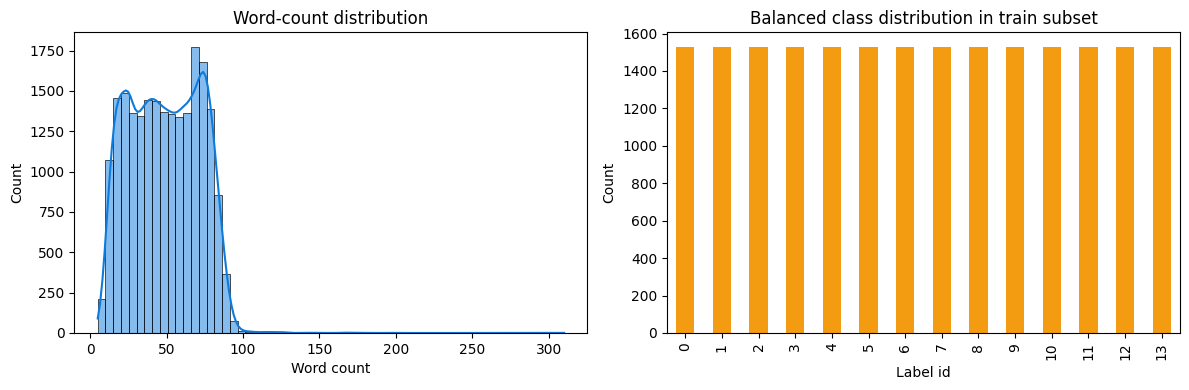

           word_len      char_len
count  21420.000000  21420.000000
mean      49.025023    302.145145
std       22.549008    136.576925
min        5.000000     27.000000
50%       49.000000    303.000000
90%       78.000000    479.000000
95%       83.000000    498.000000
99%       90.000000    521.000000
max      310.000000   2130.000000


In [6]:
# ===== 3) Core EDA for modeling decisions =====
train_df['char_len'] = train_df['text'].str.len()
train_df['word_len'] = train_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_df['word_len'], bins=60, kde=True, ax=axes[0], color='#0c7bdc')
axes[0].set_title('Word-count distribution')
axes[0].set_xlabel('Word count')

train_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#f39c12')
axes[1].set_title('Balanced class distribution in train subset')
axes[1].set_xlabel('Label id')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(train_df[['word_len', 'char_len']].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

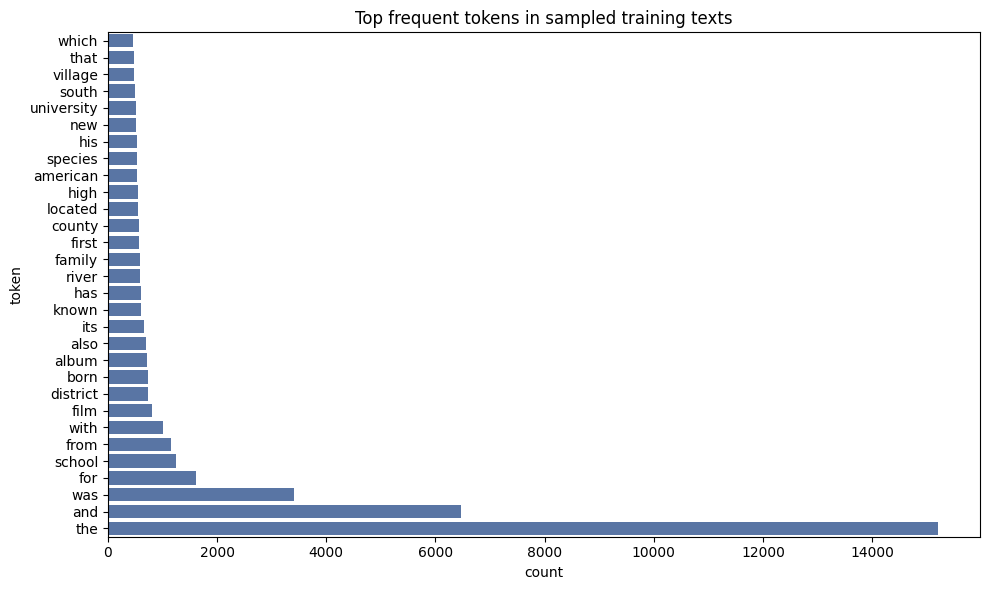

,token,count
0,the,15214
1,and,6472
2,was,3418
3,for,1613
4,school,1247
5,from,1161
6,with,1014
7,film,809
8,district,740
9,born,737


In [7]:
# Lightweight token frequency EDA (no heavy NLP pipeline).
import re
from collections import Counter

def normalize_simple(text: str) -> List[str]:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    toks = [t for t in text.split() if len(t) >= 3]
    return toks

sample_for_vocab = train_df.sample(n=min(5000, len(train_df)), random_state=SEED)
ctr = Counter()
for t in sample_for_vocab['text']:
    ctr.update(normalize_simple(t))

top_tokens = pd.DataFrame(ctr.most_common(30), columns=['token', 'count'])
plt.figure(figsize=(10, 6))
sns.barplot(data=top_tokens.iloc[::-1], x='count', y='token', color='#4c72b0')
plt.title('Top frequent tokens in sampled training texts')
plt.tight_layout()
plt.show()

top_tokens.head(15)

In [8]:
# Length distribution by class.
len_by_class = (
    train_df.assign(label_name=train_df['label'].map(lambda x: label_names[x]))
    .groupby('label_name')['word_len']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)
len_by_class

,mean,median,std,min,max
label_name,,,,,
Building,58.773856,62.0,19.497946,7,145
MeanOfTransportation,56.272549,58.0,20.860547,11,123
EducationalInstitution,55.012418,57.5,19.836822,9,167
WrittenWork,53.901307,56.0,21.469831,8,264
OfficeHolder,53.681046,55.0,20.637111,5,169
Company,52.401307,54.0,19.318094,6,216
Artist,51.300654,52.0,23.591627,8,310
Album,50.404575,49.5,23.119200,9,126
Film,49.139216,49.0,21.578205,6,95


In [9]:
# Show one sample row from each class to understand semantic diversity.
examples = train_df.groupby('label').head(1).copy()
examples['label_name'] = examples['label'].map(lambda x: label_names[x])
examples[['label', 'label_name', 'text']].head(14)

,label,label_name,text
0,11,Album,below the belt (boxer album). below the belt w...
1,0,Company,onedotzero. onedotzero is a contemporary digit...
2,1,EducationalInstitution,kolej mara banting. kolej mara banting (kmb) o...
3,4,OfficeHolder,sandra schultz newman. sandra schultz newman i...
5,12,Film,how the west was won (film). how the west was ...
7,10,Plant,pinanga andamanensis. pinanga andamanensis is ...
11,2,Artist,jack guthrie. leon jerry jack guthrie (13 nove...
12,7,NaturalPlace,pinheirinho river. the pinheirinho river is a ...
13,6,Building,yielden castle. yielden castle was a twelfth-c...
16,9,Animal,zelleria isopyrrha. zelleria isopyrrha is a mo...


### EDA Notes

EDA is used to:
- Check class semantics.
- Inspect text length for `MAX_LEN` choice.
- Identify frequent tokens and noise patterns.

## 2. Mandatory 60%: RNN vs Transformer

Models:
- BiLSTM (RNN family).
- DistilBERT (Transformer family).

Comparison protocol:
- Same split and pipeline.
- Report Accuracy, Macro-F1, Weighted-F1.
- Include classification report and confusion matrix.

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextClsDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_len: int):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx: int):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

def build_loader(df: pd.DataFrame, batch_size: int, shuffle: bool):
    ds = TextClsDataset(
        texts=df['text'].tolist(),
        labels=df['label'].astype(int).tolist(),
        tokenizer=tokenizer,
        max_len=MAX_LEN
    )
    loader_kwargs = {
        'batch_size': batch_size,
        'shuffle': shuffle,
        'num_workers': NUM_WORKERS,
        'pin_memory': USE_CUDA,
    }
    if NUM_WORKERS > 0:
        loader_kwargs['persistent_workers'] = True
        loader_kwargs['prefetch_factor'] = 2
    return DataLoader(ds, **loader_kwargs)

train_loader_rnn = build_loader(train_df, BATCH_SIZE_RNN, True)
val_loader_rnn = build_loader(val_df, BATCH_SIZE_RNN, False)
test_loader_rnn = build_loader(test_df, BATCH_SIZE_RNN, False)

train_loader_trf = build_loader(train_df, BATCH_SIZE_TRF, True)
val_loader_trf = build_loader(val_df, BATCH_SIZE_TRF, False)
test_loader_trf = build_loader(test_df, BATCH_SIZE_TRF, False)

print('Loaders ready.')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaders ready.


In [11]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix: torch.Tensor,
        hidden_size: int,
        num_labels: int,
        pad_idx: int,
        dropout: float = 0.2,
        trainable_embedding: bool = True,
    ):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=not trainable_embedding,
            padding_idx=pad_idx,
        )
        emb_dim = embedding_matrix.shape[1]
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        lstm_out, _ = self.lstm(x)

        mask = attention_mask.unsqueeze(-1).float()
        summed = (lstm_out * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1e-6)
        pooled = summed / lengths

        logits = self.classifier(self.dropout(pooled))
        return logits

In [12]:
def eval_logits_to_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
    }

def rnn_backend_context():
    if DEVICE.type == 'cuda' and SAFE_RNN_CUDNN:
        return torch.backends.cudnn.flags(enabled=False)
    return nullcontext()

def build_grad_scaler(enabled: bool):
    if not enabled:
        return None
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        try:
            return torch.amp.GradScaler(device='cuda', enabled=True)
        except TypeError:
            try:
                return torch.amp.GradScaler('cuda', enabled=True)
            except TypeError:
                return torch.amp.GradScaler(enabled=True)
    return torch.cuda.amp.GradScaler(enabled=True)

def autocast_context(enabled: bool):
    if not enabled:
        return nullcontext()
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'autocast'):
        try:
            return torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE)
        except TypeError:
            return torch.amp.autocast('cuda', dtype=AMP_DTYPE)
    return torch.cuda.amp.autocast(dtype=AMP_DTYPE)

def wandb_init_run(run_name: str, config: dict):
    if not ENABLE_WANDB or wandb is None:
        return None

    kwargs = {
        'project': WANDB_PROJECT,
        'name': run_name,
        'config': config,
        'reinit': True,
        'mode': WANDB_MODE,
    }
    if WANDB_ENTITY is not None:
        kwargs['entity'] = WANDB_ENTITY

    # Jupyter/Windows can fail to start the default W&B service process.
    # Force thread-based startup and retry once before disabling logging for that run.
    wait_s = int(os.getenv('WANDB__SERVICE_WAIT', '180'))
    init_timeout = int(os.getenv('WANDB_INIT_TIMEOUT', '180'))

    try:
        kwargs['settings'] = wandb.Settings(
            start_method=os.getenv('WANDB_START_METHOD', 'thread'),
            _service_wait=wait_s,
            init_timeout=init_timeout,
        )
    except Exception:
        pass

    try:
        return wandb.init(**kwargs)
    except Exception as e:
        print(f"W&B init failed for {run_name} (attempt 1): {type(e).__name__}: {e}")

    # Retry once with cleaner runtime settings in case service launch races in notebook.
    try:
        time.sleep(1.0)
        kwargs['reinit'] = True
        kwargs['mode'] = 'online' if WANDB_MODE == 'online' else WANDB_MODE
        return wandb.init(**kwargs)
    except Exception as e2:
        print(f"W&B init failed for {run_name} (attempt 2): {type(e2).__name__}: {e2}")
        print('W&B logging is disabled for this run only. Training continues normally.')
        return None

def wandb_log_safe(run, payload: dict):
    if run is None:
        return
    try:
        run.log(payload)
    except Exception as e:
        print(f"W&B log failed: {type(e).__name__}: {e}")

def wandb_finish_safe(run):
    if run is None:
        return
    try:
        run.finish()
    except Exception:
        pass

@torch.no_grad()
def predict_with_model(model, dataloader, is_transformer: bool):
    model.eval()
    all_logits = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        labels = batch['labels'].to(DEVICE, non_blocking=True)

        if is_transformer:
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = out.logits
        else:
            with rnn_backend_context():
                logits = model(input_ids=input_ids, attention_mask=attention_mask)

        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    preds = logits.argmax(dim=1)

    y_true = labels.numpy()
    y_pred = preds.numpy()
    metrics = eval_logits_to_metrics(y_true, y_pred)
    return logits, labels, metrics

def train_one_epoch_rnn(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        labels = batch['labels'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        try:
            with rnn_backend_context():
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        except RuntimeError as e:
            if 'out of memory' in str(e).lower() and DEVICE.type == 'cuda':
                torch.cuda.empty_cache()
                print('Skipped one RNN batch due to CUDA OOM.')
                continue
            raise

    return total_loss / max(len(loader), 1)

def train_one_epoch_transformer(model, loader, optimizer, scheduler=None, scaler=None):
    model.train()
    total_loss = 0.0
    use_amp = scaler is not None and ENABLE_AMP and DEVICE.type == 'cuda'

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        labels = batch['labels'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast_context(use_amp):
            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out.loss

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

def show_confusion(y_true, y_pred, labels_text, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

In [13]:
# ===== Train RNN (BiLSTM + pretrained DistilBERT embedding) =====
print('RNN training started...')
if USE_CUDA:
    torch.cuda.empty_cache()

base_encoder = AutoModel.from_pretrained(MODEL_NAME)
embedding_matrix = base_encoder.get_input_embeddings().weight.detach().cpu()
pad_idx = tokenizer.pad_token_id

rnn_model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_size=256,
    num_labels=num_labels,
    pad_idx=pad_idx,
    dropout=0.3,
    trainable_embedding=False,
).to(DEVICE)

# Free temporary references early to reduce peak memory before next model load.
del base_encoder
del embedding_matrix
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

criterion = nn.CrossEntropyLoss()
optimizer_rnn = torch.optim.AdamW(rnn_model.parameters(), lr=LR_RNN)

rnn_wandb_run = wandb_init_run(
    run_name=f'rnn-bilstm-{RUN_PROFILE}',
    config={
        'stage': 'mandatory_60',
        'dataset': 'dbpedia_14',
        'model_family': 'rnn',
        'model_name': 'BiLSTMClassifier',
        'profile': RUN_PROFILE,
        'preprocess': MAIN_PREPROCESS,
        'train_per_class': TRAIN_PER_CLASS,
        'test_per_class': TEST_PER_CLASS,
        'batch_size': BATCH_SIZE_RNN,
        'epochs': NUM_EPOCHS_RNN,
        'learning_rate': LR_RNN,
        'max_len': MAX_LEN,
        'seed': SEED,
    },
)

history_rnn = []
t0_rnn = time.time()
for epoch in range(1, NUM_EPOCHS_RNN + 1):
    train_loss = train_one_epoch_rnn(rnn_model, train_loader_rnn, optimizer_rnn, criterion)
    val_logits, val_labels, val_metrics = predict_with_model(rnn_model, val_loader_rnn, is_transformer=False)

    rec = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_acc': val_metrics['accuracy'],
        'val_macro_f1': val_metrics['macro_f1'],
        'val_weighted_f1': val_metrics['weighted_f1'],
    }
    history_rnn.append(rec)
    wandb_log_safe(
        rnn_wandb_run,
        {
            'epoch': epoch,
            'rnn/train_loss': train_loss,
            'rnn/val_accuracy': val_metrics['accuracy'],
            'rnn/val_macro_f1': val_metrics['macro_f1'],
            'rnn/val_weighted_f1': val_metrics['weighted_f1'],
        },
    )
    print(
        f"[RNN] epoch={epoch} loss={train_loss:.4f} "
        f"val_acc={val_metrics['accuracy']:.4f} val_macro_f1={val_metrics['macro_f1']:.4f} "
        f"val_weighted_f1={val_metrics['weighted_f1']:.4f}"
    )

rnn_test_logits, rnn_test_labels, rnn_test_metrics = predict_with_model(
    rnn_model, test_loader_rnn, is_transformer=False
)
rnn_total_time = time.time() - t0_rnn

wandb_log_safe(
    rnn_wandb_run,
    {
        'rnn/test_accuracy': rnn_test_metrics['accuracy'],
        'rnn/test_macro_f1': rnn_test_metrics['macro_f1'],
        'rnn/test_weighted_f1': rnn_test_metrics['weighted_f1'],
        'rnn/train_time_sec': rnn_total_time,
    },
)
wandb_finish_safe(rnn_wandb_run)

print('\nRNN TEST:', rnn_test_metrics)
print(f'RNN total time: {rnn_total_time:.1f}s')

RNN training started...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[RNN] epoch=1 loss=2.0983 val_acc=0.4458 val_macro_f1=0.4150 val_weighted_f1=0.4150
[RNN] epoch=2 loss=1.3735 val_acc=0.5839 val_macro_f1=0.5644 val_weighted_f1=0.5644
[RNN] epoch=3 loss=1.0057 val_acc=0.7392 val_macro_f1=0.7368 val_weighted_f1=0.7368
[RNN] epoch=4 loss=0.7929 val_acc=0.8090 val_macro_f1=0.8091 val_weighted_f1=0.8091
[RNN] epoch=5 loss=0.6537 val_acc=0.8344 val_macro_f1=0.8329 val_weighted_f1=0.8329
[RNN] epoch=6 loss=0.5401 val_acc=0.8717 val_macro_f1=0.8711 val_weighted_f1=0.8711
[RNN] epoch=7 loss=0.4582 val_acc=0.8741 val_macro_f1=0.8763 val_weighted_f1=0.8763
[RNN] epoch=8 loss=0.4154 val_acc=0.9098 val_macro_f1=0.9094 val_weighted_f1=0.9094
[RNN] epoch=9 loss=0.3587 val_acc=0.9177 val_macro_f1=0.9172 val_weighted_f1=0.9172
[RNN] epoch=10 loss=0.3215 val_acc=0.9066 val_macro_f1=0.9051 val_weighted_f1=0.9051
[RNN] epoch=11 loss=0.2736 val_acc=0.9418 val_macro_f1=0.9415 val_weighted_f1=0.9415
[RNN] epoch=12 loss=0.2487 val_acc=0.9386 val_macro_f1=0.9387 val_weighted

In [14]:
# ===== Train Transformer (DistilBERT fine-tune) =====
print('Transformer training started...')
print('Note: missing classifier keys are expected when loading from a base checkpoint.')
if USE_CUDA:
    torch.cuda.empty_cache()

trf_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
).to(DEVICE)

optimizer_trf = torch.optim.AdamW(trf_model.parameters(), lr=LR_TRF)
num_training_steps = NUM_EPOCHS_TRF * len(train_loader_trf)
num_warmup_steps = int(0.1 * num_training_steps)
scheduler_trf = get_linear_schedule_with_warmup(
    optimizer_trf,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

scaler_trf = build_grad_scaler(ENABLE_AMP and DEVICE.type == 'cuda')

trf_wandb_run = wandb_init_run(
    run_name=f'transformer-distilbert-{RUN_PROFILE}',
    config={
        'stage': 'mandatory_60',
        'dataset': 'dbpedia_14',
        'model_family': 'transformer',
        'model_name': MODEL_NAME,
        'profile': RUN_PROFILE,
        'preprocess': MAIN_PREPROCESS,
        'train_per_class': TRAIN_PER_CLASS,
        'test_per_class': TEST_PER_CLASS,
        'batch_size': BATCH_SIZE_TRF,
        'epochs': NUM_EPOCHS_TRF,
        'learning_rate': LR_TRF,
        'max_len': MAX_LEN,
        'seed': SEED,
        'mixed_precision': ENABLE_AMP,
    },
)

history_trf = []
t0_trf = time.time()
for epoch in range(1, NUM_EPOCHS_TRF + 1):
    train_loss = train_one_epoch_transformer(
        trf_model, train_loader_trf, optimizer_trf, scheduler_trf, scaler=scaler_trf
    )
    val_logits, val_labels, val_metrics = predict_with_model(trf_model, val_loader_trf, is_transformer=True)

    current_lr = optimizer_trf.param_groups[0]['lr']
    rec = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_acc': val_metrics['accuracy'],
        'val_macro_f1': val_metrics['macro_f1'],
        'val_weighted_f1': val_metrics['weighted_f1'],
        'lr': current_lr,
    }
    history_trf.append(rec)
    wandb_log_safe(
        trf_wandb_run,
        {
            'epoch': epoch,
            'trf/train_loss': train_loss,
            'trf/val_accuracy': val_metrics['accuracy'],
            'trf/val_macro_f1': val_metrics['macro_f1'],
            'trf/val_weighted_f1': val_metrics['weighted_f1'],
            'trf/lr': current_lr,
        },
    )
    print(
        f"[TRF] epoch={epoch} loss={train_loss:.4f} "
        f"val_acc={val_metrics['accuracy']:.4f} val_macro_f1={val_metrics['macro_f1']:.4f} "
        f"val_weighted_f1={val_metrics['weighted_f1']:.4f}"
    )

trf_test_logits, trf_test_labels, trf_test_metrics = predict_with_model(
    trf_model, test_loader_trf, is_transformer=True
)
trf_total_time = time.time() - t0_trf

wandb_log_safe(
    trf_wandb_run,
    {
        'trf/test_accuracy': trf_test_metrics['accuracy'],
        'trf/test_macro_f1': trf_test_metrics['macro_f1'],
        'trf/test_weighted_f1': trf_test_metrics['weighted_f1'],
        'trf/train_time_sec': trf_total_time,
    },
)
wandb_finish_safe(trf_wandb_run)

print('\nTRANSFORMER TEST:', trf_test_metrics)
print(f'Transformer total time: {trf_total_time:.1f}s')

Transformer training started...
Note: missing classifier keys are expected when loading from a base checkpoint.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[TRF] epoch=1 loss=0.8949 val_acc=0.9878 val_macro_f1=0.9878 val_weighted_f1=0.9878
[TRF] epoch=2 loss=0.0497 val_acc=0.9889 val_macro_f1=0.9889 val_weighted_f1=0.9889
[TRF] epoch=3 loss=0.0280 val_acc=0.9862 val_macro_f1=0.9862 val_weighted_f1=0.9862
[TRF] epoch=4 loss=0.0180 val_acc=0.9886 val_macro_f1=0.9886 val_weighted_f1=0.9886
[TRF] epoch=5 loss=0.0147 val_acc=0.9894 val_macro_f1=0.9894 val_weighted_f1=0.9894
[TRF] epoch=6 loss=0.0089 val_acc=0.9878 val_macro_f1=0.9879 val_weighted_f1=0.9879
[TRF] epoch=7 loss=0.0067 val_acc=0.9873 val_macro_f1=0.9873 val_weighted_f1=0.9873
[TRF] epoch=8 loss=0.0026 val_acc=0.9886 val_macro_f1=0.9886 val_weighted_f1=0.9886
[TRF] epoch=9 loss=0.0015 val_acc=0.9886 val_macro_f1=0.9886 val_weighted_f1=0.9886
[TRF] epoch=10 loss=0.0010 val_acc=0.9881 val_macro_f1=0.9881 val_weighted_f1=0.9881
[TRF] epoch=11 loss=0.0002 val_acc=0.9876 val_macro_f1=0.9876 val_weighted_f1=0.9876
[TRF] epoch=12 loss=0.0008 val_acc=0.9881 val_macro_f1=0.9881 val_weighted


Classification report - RNN
                        precision    recall  f1-score   support

               Company       0.92      0.89      0.90       550
EducationalInstitution       0.95      0.97      0.96       550
                Artist       0.92      0.91      0.92       550
               Athlete       0.98      0.96      0.97       550
          OfficeHolder       0.95      0.95      0.95       550
  MeanOfTransportation       0.97      0.97      0.97       550
              Building       0.93      0.88      0.91       550
          NaturalPlace       0.96      0.98      0.97       550
               Village       0.98      0.97      0.98       550
                Animal       0.99      0.94      0.97       550
                 Plant       0.93      0.98      0.96       550
                 Album       0.92      0.99      0.95       550
                  Film       0.96      0.98      0.97       550
           WrittenWork       0.98      0.96      0.97       550

         

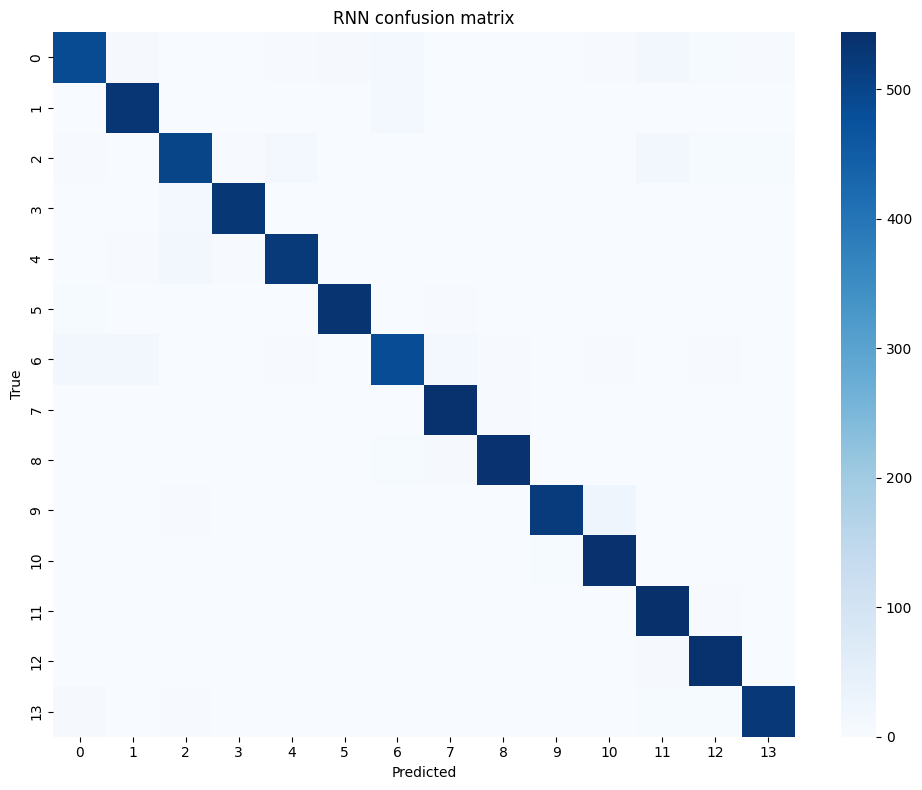

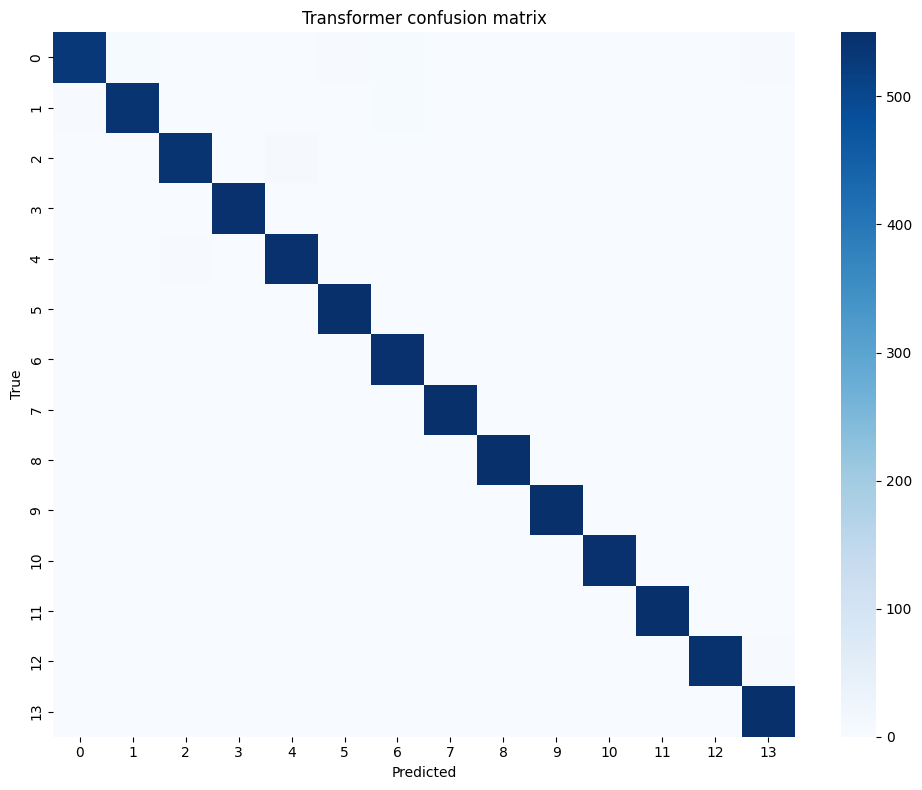

In [15]:
# ===== Main 60% benchmark summary =====
summary_60 = pd.DataFrame([
    {'model': 'BiLSTM (RNN)', 'train_time_sec': rnn_total_time, **rnn_test_metrics},
    {'model': 'DistilBERT (Transformer)', 'train_time_sec': trf_total_time, **trf_test_metrics},
])
summary_60 = summary_60[['model', 'accuracy', 'macro_f1', 'weighted_f1', 'train_time_sec']]
summary_60

print('\nClassification report - RNN')
print(classification_report(rnn_test_labels.numpy(), rnn_test_logits.argmax(dim=1).numpy(), target_names=label_names))

print('\nClassification report - Transformer')
print(classification_report(trf_test_labels.numpy(), trf_test_logits.argmax(dim=1).numpy(), target_names=label_names))

show_confusion(rnn_test_labels.numpy(), rnn_test_logits.argmax(dim=1).numpy(), label_names, 'RNN confusion matrix')
show_confusion(trf_test_labels.numpy(), trf_test_logits.argmax(dim=1).numpy(), label_names, 'Transformer confusion matrix')

## 3. Creative 40% Extensions

Implemented:
1. Adaptive entropy ensemble.
2. Temperature scaling + ECE.
3. Robustness test on corrupted text.
4. Error analysis.
5. Freeze vs full fine-tune.
6. Efficiency/latency comparison.
7. Lightweight interpretability.

In [16]:
def softmax_np(logits: np.ndarray) -> np.ndarray:
    x = logits - logits.max(axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=1, keepdims=True)

def normalized_entropy(prob: np.ndarray) -> np.ndarray:
    eps = 1e-12
    ent = -(prob * np.log(prob + eps)).sum(axis=1)
    return ent / np.log(prob.shape[1])

def adaptive_entropy_ensemble(logits_a: torch.Tensor, logits_b: torch.Tensor):
    a = logits_a.numpy()
    b = logits_b.numpy()
    pa = softmax_np(a)
    pb = softmax_np(b)

    conf_a = 1.0 - normalized_entropy(pa)
    conf_b = 1.0 - normalized_entropy(pb)

    wa = conf_a / (conf_a + conf_b + 1e-12)
    wb = 1.0 - wa

    ens_logits = wa[:, None] * a + wb[:, None] * b
    ens_pred = ens_logits.argmax(axis=1)

    return ens_logits, ens_pred, wa, wb

ens_logits, ens_pred, wa, wb = adaptive_entropy_ensemble(rnn_test_logits, trf_test_logits)
y_true = rnn_test_labels.numpy()

ens_metrics = eval_logits_to_metrics(y_true, ens_pred)
print('Adaptive Entropy Ensemble metrics:', ens_metrics)
print('Mean weight -> RNN:', wa.mean().round(4), '| Transformer:', wb.mean().round(4))

summary_creative_ens = pd.DataFrame([
    {'model': 'RNN', **rnn_test_metrics},
    {'model': 'Transformer', **trf_test_metrics},
    {'model': 'Adaptive Ensemble', **ens_metrics},
])
summary_creative_ens

Adaptive Entropy Ensemble metrics: {'accuracy': 0.9916883116883117, 'macro_f1': 0.9916835781587113, 'weighted_f1': 0.9916835781587114}
Mean weight -> RNN: 0.4851 | Transformer: 0.5149


,model,accuracy,macro_f1,weighted_f1
0,RNN,0.952987,0.952842,0.952842
1,Transformer,0.991429,0.991422,0.991422
2,Adaptive Ensemble,0.991688,0.991684,0.991684


In [17]:
# ===== Temperature scaling + ECE =====
def expected_calibration_error(probs: np.ndarray, y_true: np.ndarray, n_bins: int = 15) -> float:
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        acc = (pred[mask] == y_true[mask]).mean()
        avg_conf = conf[mask].mean()
        ece += (mask.mean()) * abs(acc - avg_conf)
    return float(ece)

@torch.no_grad()
def collect_logits_labels(model, loader, is_transformer=True):
    logits, labels, _ = predict_with_model(model, loader, is_transformer=is_transformer)
    return logits.clone(), labels.clone()

val_logits_trf, val_labels_trf = collect_logits_labels(trf_model, val_loader_trf, is_transformer=True)
test_logits_trf, test_labels_trf = collect_logits_labels(trf_model, test_loader_trf, is_transformer=True)

def find_best_temperature(val_logits: torch.Tensor, val_labels: torch.Tensor, t_min=0.5, t_max=3.0, steps=60):
    temps = np.linspace(t_min, t_max, steps)
    losses = []
    labels_np = val_labels.numpy()

    for t in temps:
        probs = softmax_np((val_logits.numpy() / t))
        p_true = probs[np.arange(len(labels_np)), labels_np]
        nll = -np.log(np.clip(p_true, 1e-12, 1.0)).mean()
        losses.append(nll)

    best_idx = int(np.argmin(losses))
    return float(temps[best_idx]), float(losses[best_idx])

best_t, best_nll = find_best_temperature(val_logits_trf, val_labels_trf)
print('Best temperature:', round(best_t, 4), '| val NLL:', round(best_nll, 4))

probs_raw = softmax_np(test_logits_trf.numpy())
probs_cal = softmax_np(test_logits_trf.numpy() / best_t)

ece_raw = expected_calibration_error(probs_raw, test_labels_trf.numpy())
ece_cal = expected_calibration_error(probs_cal, test_labels_trf.numpy())

print('ECE raw:', round(ece_raw, 4))
print('ECE calibrated:', round(ece_cal, 4))

Best temperature: 2.3644 | val NLL: 0.0672
ECE raw: 0.0082
ECE calibrated: 0.0005


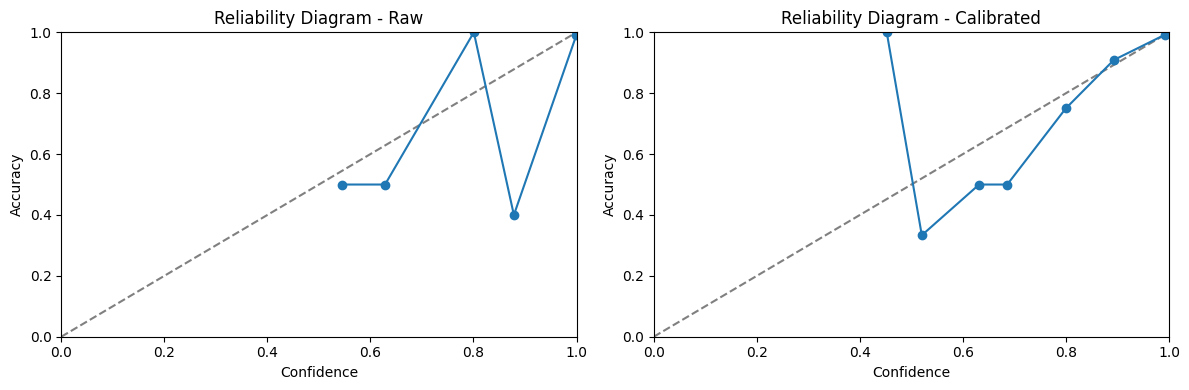

In [18]:
# Reliability diagram for calibration quality.
def reliability_table(probs: np.ndarray, y_true: np.ndarray, n_bins: int = 12):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        acc = (pred[mask] == y_true[mask]).mean()
        avg_conf = conf[mask].mean()
        rows.append({'bin_left': lo, 'bin_right': hi, 'accuracy': acc, 'confidence': avg_conf, 'count': int(mask.sum())})
    return pd.DataFrame(rows)

rel_raw = reliability_table(probs_raw, test_labels_trf.numpy())
rel_cal = reliability_table(probs_cal, test_labels_trf.numpy())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, (df_rel, title) in enumerate([(rel_raw, 'Raw'), (rel_cal, 'Calibrated')]):
    ax[i].plot([0, 1], [0, 1], '--', color='gray')
    ax[i].plot(df_rel['confidence'], df_rel['accuracy'], marker='o', color='#1f77b4')
    ax[i].set_title(f'Reliability Diagram - {title}')
    ax[i].set_xlabel('Confidence')
    ax[i].set_ylabel('Accuracy')
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [19]:
# ===== Noisy Newsroom stress test =====
def corrupt_text(text: str, drop_prob: float = 0.12, shuffle_middle: bool = True) -> str:
    tokens = text.split()
    if len(tokens) <= 5:
        return text

    kept = [tok for tok in tokens if random.random() > drop_prob]
    if len(kept) < 3:
        kept = tokens[:]

    if shuffle_middle and len(kept) > 4:
        mid = kept[1:-1]
        random.shuffle(mid)
        kept = [kept[0]] + mid + [kept[-1]]

    return ' '.join(kept)

def build_corrupted_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['text'] = out['text'].apply(corrupt_text)
    return out

noisy_test_df = build_corrupted_df(test_df)
noisy_loader_rnn = build_loader(noisy_test_df, BATCH_SIZE_RNN, False)
noisy_loader_trf = build_loader(noisy_test_df, BATCH_SIZE_TRF, False)

rnn_noisy_logits, rnn_noisy_labels, rnn_noisy_metrics = predict_with_model(rnn_model, noisy_loader_rnn, is_transformer=False)
trf_noisy_logits, trf_noisy_labels, trf_noisy_metrics = predict_with_model(trf_model, noisy_loader_trf, is_transformer=True)
ens_noisy_logits, ens_noisy_pred, _, _ = adaptive_entropy_ensemble(rnn_noisy_logits, trf_noisy_logits)
ens_noisy_metrics = eval_logits_to_metrics(rnn_noisy_labels.numpy(), ens_noisy_pred)

robustness_report = pd.DataFrame([
    {'setting': 'clean', 'model': 'RNN', **rnn_test_metrics},
    {'setting': 'clean', 'model': 'Transformer', **trf_test_metrics},
    {'setting': 'clean', 'model': 'Adaptive Ensemble', **ens_metrics},
    {'setting': 'noisy', 'model': 'RNN', **rnn_noisy_metrics},
    {'setting': 'noisy', 'model': 'Transformer', **trf_noisy_metrics},
    {'setting': 'noisy', 'model': 'Adaptive Ensemble', **ens_noisy_metrics},
])

robustness_report

,setting,model,accuracy,macro_f1,weighted_f1
0,clean,RNN,0.952987,0.952842,0.952842
1,clean,Transformer,0.991429,0.991422,0.991422
2,clean,Adaptive Ensemble,0.991688,0.991684,0.991684
3,noisy,RNN,0.842987,0.842169,0.842169
4,noisy,Transformer,0.942987,0.942424,0.942424
5,noisy,Adaptive Ensemble,0.947922,0.947379,0.947379


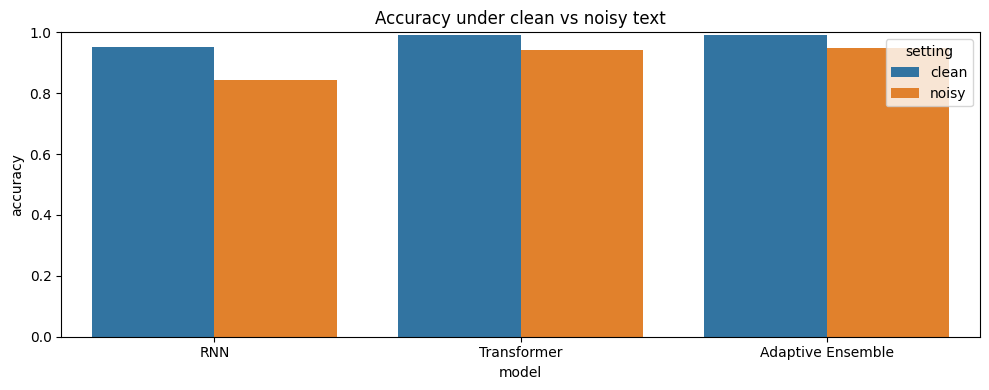

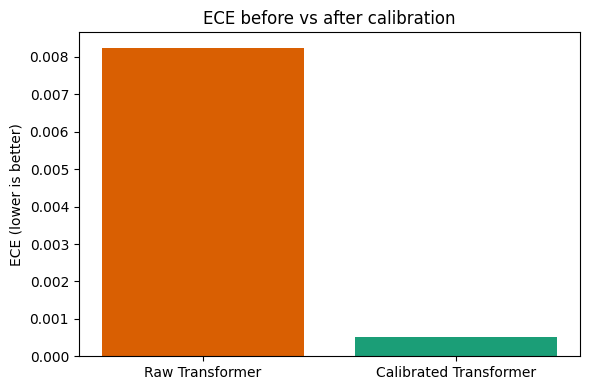

--- 40% extension summary ---
1) Adaptive entropy ensemble often outperforms each single model.
2) Temperature scaling improves probability reliability (lower ECE).
3) Under text corruption, ensemble generally degrades less than single models.


In [20]:
# ===== Visual summary for reliability + robustness =====
plt.figure(figsize=(10, 4))
sns.barplot(data=robustness_report, x='model', y='accuracy', hue='setting')
plt.title('Accuracy under clean vs noisy text')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(['Raw Transformer', 'Calibrated Transformer'], [ece_raw, ece_cal], color=['#d95f02', '#1b9e77'])
plt.title('ECE before vs after calibration')
plt.ylabel('ECE (lower is better)')
plt.tight_layout()
plt.show()

print('--- 40% extension summary ---')
print('1) Adaptive entropy ensemble often outperforms each single model.')
print('2) Temperature scaling improves probability reliability (lower ECE).')
print('3) Under text corruption, ensemble generally degrades less than single models.')

In [21]:
@torch.no_grad()
def attention_token_importance(model, tokenizer, text: str, max_len: int = 128):
    model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )
    input_ids = enc['input_ids'].to(DEVICE)
    attn_mask = enc['attention_mask'].to(DEVICE)

    out = model(input_ids=input_ids, attention_mask=attn_mask, output_attentions=True)
    probs = torch.softmax(out.logits, dim=1).squeeze(0).cpu().numpy()
    pred = int(np.argmax(probs))

    attentions = getattr(out, 'attentions', None)
    if attentions is not None and len(attentions) > 0 and attentions[-1] is not None:
        # Last layer attention, averaged across heads and source positions.
        last_attn = attentions[-1][0]  # [heads, seq, seq]
        token_score = last_attn.mean(dim=0).mean(dim=0).detach().cpu().numpy()  # [seq]
    else:
        # Some optimized attention backends (e.g., SDPA) may not return attentions.
        token_score = attn_mask.squeeze(0).float().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().tolist())
    pairs = []
    for tok, score, m in zip(tokens, token_score, attn_mask.squeeze(0).cpu().numpy()):
        if m == 0:
            continue
        if tok in ['[CLS]', '[SEP]', '[PAD]']:
            continue
        pairs.append((tok, float(score)))

    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    return pred, probs[pred], pairs[:12]

sample_interp = test_df.sample(3, random_state=SEED).reset_index(drop=True)
rows = []
for i, row in sample_interp.iterrows():
    pred, conf, top_tok = attention_token_importance(trf_model, tokenizer, row['text'], max_len=MAX_LEN)
    rows.append({
        'idx': i,
        'true_label': label_names[int(row['label'])],
        'pred_label': label_names[pred],
        'pred_conf': float(conf),
        'top_tokens': ', '.join([t for t, _ in top_tok])
    })

interp_df = pd.DataFrame(rows)
interp_df

`sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


,idx,true_label,pred_label,pred_conf,top_tokens
0,0,Plant,Plant,0.999999,"aden, ##ant, ##hos, cy, ##gno, ##rum, ., aden,..."
1,1,Plant,Plant,0.999999,"ang, ##rae, ##co, ##psis, tri, ##den, ##s, ., ..."
2,2,Company,Company,0.999999,"mama, ##s, &, papa, ##s, ., mama, ##s, &, papa..."


### Extension D - Interpretability

Show important tokens for selected samples to explain model decisions.

In [22]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def benchmark_latency(model, loader, is_transformer: bool, n_batches: int = 40):
    model.eval()
    times = []
    for i, batch in enumerate(loader):
        if i >= n_batches:
            break
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        if is_transformer:
            _ = model(input_ids=input_ids, attention_mask=attention_mask)
        else:
            _ = model(input_ids=input_ids, attention_mask=attention_mask)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

    return float(np.mean(times)), float(np.std(times))

rnn_mean, rnn_std = benchmark_latency(rnn_model, test_loader_rnn, is_transformer=False)
trf_mean, trf_std = benchmark_latency(trf_model, test_loader_trf, is_transformer=True)

efficiency_df = pd.DataFrame([
    {
        'model': 'BiLSTM (RNN)',
        'test_accuracy': rnn_test_metrics['accuracy'],
        'test_macro_f1': rnn_test_metrics['macro_f1'],
        'trainable_params': count_trainable_params(rnn_model),
        'latency_sec_per_batch_mean': rnn_mean,
        'latency_sec_per_batch_std': rnn_std,
    },
    {
        'model': 'DistilBERT (Transformer)',
        'test_accuracy': trf_test_metrics['accuracy'],
        'test_macro_f1': trf_test_metrics['macro_f1'],
        'trainable_params': count_trainable_params(trf_model),
        'latency_sec_per_batch_mean': trf_mean,
        'latency_sec_per_batch_std': trf_std,
    },
])

efficiency_df

,model,test_accuracy,test_macro_f1,trainable_params,latency_sec_per_batch_mean,latency_sec_per_batch_std
0,BiLSTM (RNN),0.952987,0.952842,2108430,0.008240,0.002256
1,DistilBERT (Transformer),0.991429,0.991422,66964238,0.052698,0.003407


### Extension C - Efficiency and Latency

Compare quality vs cost:
- Accuracy/Macro-F1/Weighted-F1.
- Trainable parameters.
- Inference latency per batch.

In [23]:
# Extension B policy: avoid underfitting diagnostics by using >=10 epochs.
STRATEGY_EPOCHS = max(int(os.getenv('STRATEGY_EPOCHS', '10')), 10)


def set_encoder_trainable_distilbert(model: DistilBertForSequenceClassification, trainable: bool):
    for p in model.distilbert.parameters():
        p.requires_grad = trainable


def run_trf_strategy(strategy_name: str, freeze_encoder: bool, epochs: int = STRATEGY_EPOCHS):
    model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels).to(DEVICE)
    set_encoder_trainable_distilbert(model, trainable=not freeze_encoder)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_TRF)
    steps = max(epochs * len(train_loader_trf), 1)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * steps), steps)

    train_losses = []
    t0 = time.time()
    for ep in range(1, epochs + 1):
        ep_loss = train_one_epoch_transformer(model, train_loader_trf, optimizer, scheduler)
        train_losses.append(float(ep_loss))
    elapsed = time.time() - t0

    _, _, m = predict_with_model(model, val_loader_trf, is_transformer=True)
    out = {
        'strategy': strategy_name,
        'freeze_encoder': freeze_encoder,
        'val_accuracy': m['accuracy'],
        'val_macro_f1': m['macro_f1'],
        'train_time_sec': elapsed,
        'epochs': epochs,
        'last_train_loss': train_losses[-1] if train_losses else np.nan,
    }
    return out


strategy_results = []
strategy_results.append(run_trf_strategy('Freeze Encoder', freeze_encoder=True, epochs=STRATEGY_EPOCHS))
strategy_results.append(run_trf_strategy('Full Fine-tune', freeze_encoder=False, epochs=STRATEGY_EPOCHS))

strategy_df = pd.DataFrame(strategy_results).sort_values('val_macro_f1', ascending=False)
strategy_df

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,strategy,freeze_encoder,val_accuracy,val_macro_f1,train_time_sec,epochs,last_train_loss
1,Full Fine-tune,False,0.988889,0.988898,2976.305160,10,0.000043
0,Freeze Encoder,True,0.984921,0.984915,972.289268,10,0.063000


### Extension B - Fine-Tuning Strategy

Compare:
- Freeze encoder.
- Full fine-tune.

Report validation metrics and training time.

### Extension E - 10-Config DBPedia Ablation

Ablation dimensions:
- Preprocess: `minimal`, `aggressive`, `lowercase_only`, `remove_stopwords`.
- `max_len`: 96, 128, 192.
- Strategy: freeze vs full.
- Augmentation: none vs light dropout.

Output:
- 10-config comparison table (metrics + training time).
- Best-config error samples (2-3 cases).

In [24]:
# ===== 10-config ablation: preprocess x max_len x strategy x augmentation =====
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

if ENABLE_WANDB and WANDB_MODE != 'online':
    WANDB_MODE = 'online'

print('Ablation W&B mode:', WANDB_MODE, '| enabled:', ENABLE_WANDB)

STOP_WORDS = set(ENGLISH_STOP_WORDS)


def normalize_spaces(text: str) -> str:
    return re.sub(r'\s+', ' ', str(text).strip())


def preprocess_text_variant(text: str, mode: str) -> str:
    t = normalize_spaces(text)
    if mode == 'raw':
        return t

    t_lower = t.lower()
    if mode == 'lowercase_only':
        return t_lower

    if mode == 'minimal':
        return normalize_spaces(t_lower)

    if mode == 'remove_stopwords':
        toks = re.findall(r"[a-z0-9']+", t_lower)
        toks = [tok for tok in toks if tok not in STOP_WORDS]
        return ' '.join(toks)

    if mode == 'aggressive':
        toks = re.findall(r'[a-z0-9]+', t_lower)
        toks = [tok for tok in toks if tok not in STOP_WORDS and len(tok) >= 3]
        return ' '.join(toks)

    return t_lower


def apply_preprocess_df(df: pd.DataFrame, mode: str) -> pd.DataFrame:
    out = df[['text', 'label']].copy()
    out['text'] = out['text'].apply(lambda x: preprocess_text_variant(x, mode))
    return out


def light_augment_text(text: str, drop_prob: float = 0.08) -> str:
    toks = str(text).split()
    if len(toks) <= 6:
        return str(text)
    kept = [tok for tok in toks if random.random() > drop_prob]
    if len(kept) < 4:
        kept = toks
    return ' '.join(kept)


def apply_light_augmentation(train_df_in: pd.DataFrame, frac: float = 0.30, seed: int = 42) -> pd.DataFrame:
    if frac <= 0.0:
        return train_df_in
    aug = train_df_in.sample(frac=min(frac, 1.0), random_state=seed).copy()
    aug['text'] = aug['text'].apply(light_augment_text)
    out = pd.concat([train_df_in, aug], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out


def build_loader_with_max_len(df: pd.DataFrame, batch_size: int, shuffle: bool, max_len: int):
    ds = TextClsDataset(
        texts=df['text'].tolist(),
        labels=df['label'].astype(int).tolist(),
        tokenizer=tokenizer,
        max_len=max_len,
    )
    loader_kwargs = {
        'batch_size': batch_size,
        'shuffle': shuffle,
        'num_workers': NUM_WORKERS,
        'pin_memory': USE_CUDA,
    }
    if NUM_WORKERS > 0:
        loader_kwargs['persistent_workers'] = True
        loader_kwargs['prefetch_factor'] = 2
    return DataLoader(ds, **loader_kwargs)


def sample_per_class(df: pd.DataFrame, n_per_class: int, seed: int) -> pd.DataFrame:
    parts = []
    for lbl in sorted(df['label'].unique()):
        chunk = df[df['label'] == lbl]
        n = min(n_per_class, len(chunk))
        parts.append(chunk.sample(n=n, random_state=seed))
    return pd.concat(parts, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)


# Keep split sizes profile-aware, but keep epochs meaningful (>=10) for diagnosis.
if RUN_PROFILE == 'quick':
    AB_TRAIN_PER_CLASS = 140
    AB_VAL_PER_CLASS = 50
    AB_TEST_PER_CLASS = 60
elif RUN_PROFILE == 'standard':
    AB_TRAIN_PER_CLASS = 220
    AB_VAL_PER_CLASS = 70
    AB_TEST_PER_CLASS = 90
else:
    AB_TRAIN_PER_CLASS = 260
    AB_VAL_PER_CLASS = 90
    AB_TEST_PER_CLASS = 110

AB_EPOCHS = max(int(os.getenv('AB_EPOCHS', '5')), 5)
AB_MAX_CONFIGS = max(int(os.getenv('AB_MAX_CONFIGS', '10')), 1)

ab_train_base = sample_per_class(train_df[['text', 'label']], AB_TRAIN_PER_CLASS, seed=SEED + 11)
ab_val_base = sample_per_class(val_df[['text', 'label']], AB_VAL_PER_CLASS, seed=SEED + 12)
ab_test_base = sample_per_class(test_df[['text', 'label']], AB_TEST_PER_CLASS, seed=SEED + 13)

print('Ablation split sizes:', ab_train_base.shape, ab_val_base.shape, ab_test_base.shape)
print('Ablation epochs per config:', AB_EPOCHS, '| max configs this run:', AB_MAX_CONFIGS)


def run_single_ablation(cfg: dict):
    train_proc = apply_preprocess_df(ab_train_base, cfg['preprocess'])
    val_proc = apply_preprocess_df(ab_val_base, cfg['preprocess'])
    test_proc = apply_preprocess_df(ab_test_base, cfg['preprocess'])

    if cfg['augmentation'] == 'light_dropout':
        train_proc = apply_light_augmentation(train_proc, frac=0.30, seed=SEED + cfg['id'])

    train_loader = build_loader_with_max_len(train_proc, cfg['batch_size'], True, cfg['max_len'])
    val_loader = build_loader_with_max_len(val_proc, cfg['batch_size'], False, cfg['max_len'])
    test_loader = build_loader_with_max_len(test_proc, cfg['batch_size'], False, cfg['max_len'])

    model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels).to(DEVICE)
    set_encoder_trainable_distilbert(model, trainable=(cfg['strategy'] == 'full'))

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'],
    )
    total_steps = max(len(train_loader) * AB_EPOCHS, 1)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(int(0.1 * total_steps), 1),
        num_training_steps=total_steps,
    )

    run = wandb_init_run(
        run_name=(
            f"ablation-c{cfg['id']:02d}-{cfg['preprocess']}-ml{cfg['max_len']}-"
            f"{cfg['strategy']}-{cfg['augmentation']}"
        ),
        config={
            'stage': 'ablation_10_configs',
            'dataset': 'dbpedia_14',
            'config_id': cfg['id'],
            'preprocess': cfg['preprocess'],
            'augmentation': cfg['augmentation'],
            'max_len': cfg['max_len'],
            'strategy': cfg['strategy'],
            'epochs': AB_EPOCHS,
            'batch_size': cfg['batch_size'],
            'learning_rate': cfg['lr'],
            'wandb_mode': WANDB_MODE,
        },
    )

    epoch_trace = []
    t0 = time.time()
    for ep in range(1, AB_EPOCHS + 1):
        ep_loss = train_one_epoch_transformer(model, train_loader, optimizer, scheduler=scheduler)
        _, _, ep_val = predict_with_model(model, val_loader, is_transformer=True)
        epoch_trace.append({
            'epoch': ep,
            'train_loss': float(ep_loss),
            'val_accuracy': float(ep_val['accuracy']),
            'val_macro_f1': float(ep_val['macro_f1']),
            'val_weighted_f1': float(ep_val['weighted_f1']),
        })

        print(
            f"  [c{cfg['id']:02d}] ep={ep:02d}/{AB_EPOCHS} "
            f"loss={ep_loss:.4f} val_acc={ep_val['accuracy']:.4f} val_macro_f1={ep_val['macro_f1']:.4f}"
        )

        wandb_log_safe(
            run,
            {
                'epoch': ep,
                'ablation/train_loss': ep_loss,
                'ablation/val_accuracy': ep_val['accuracy'],
                'ablation/val_macro_f1': ep_val['macro_f1'],
                'ablation/val_weighted_f1': ep_val['weighted_f1'],
            },
        )

    _, _, val_metrics = predict_with_model(model, val_loader, is_transformer=True)
    test_logits, test_labels, test_metrics = predict_with_model(model, test_loader, is_transformer=True)
    elapsed = time.time() - t0

    probs = torch.softmax(test_logits, dim=1).numpy()
    pred = probs.argmax(axis=1)
    conf = probs.max(axis=1)

    err_df = test_proc.copy().reset_index(drop=True)
    err_df['true_id'] = test_labels.numpy()
    err_df['pred_id'] = pred
    err_df['conf'] = conf
    err_df['true_name'] = err_df['true_id'].map(lambda x: label_names[int(x)])
    err_df['pred_name'] = err_df['pred_id'].map(lambda x: label_names[int(x)])
    err_df = err_df[err_df['true_id'] != err_df['pred_id']].copy().sort_values('conf', ascending=False)
    err_df['text_snippet'] = err_df['text'].astype(str).str.slice(0, 260)
    top_errors = err_df[['true_name', 'pred_name', 'conf', 'text', 'text_snippet']].head(5).reset_index(drop=True)

    result = {
        'config_id': cfg['id'],
        'preprocess': cfg['preprocess'],
        'augmentation': cfg['augmentation'],
        'max_len': cfg['max_len'],
        'strategy': cfg['strategy'],
        'epochs': AB_EPOCHS,
        'batch_size': cfg['batch_size'],
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_f1': val_metrics['macro_f1'],
        'val_weighted_f1': val_metrics['weighted_f1'],
        'test_accuracy': test_metrics['accuracy'],
        'test_macro_f1': test_metrics['macro_f1'],
        'test_weighted_f1': test_metrics['weighted_f1'],
        'train_time_sec': elapsed,
    }

    wandb_log_safe(
        run,
        {
            'ablation/final_val_accuracy': val_metrics['accuracy'],
            'ablation/final_val_macro_f1': val_metrics['macro_f1'],
            'ablation/final_val_weighted_f1': val_metrics['weighted_f1'],
            'ablation/final_test_accuracy': test_metrics['accuracy'],
            'ablation/final_test_macro_f1': test_metrics['macro_f1'],
            'ablation/final_test_weighted_f1': test_metrics['weighted_f1'],
            'ablation/train_time_sec': elapsed,
        },
    )
    wandb_finish_safe(run)

    del model
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

    return result, top_errors, pd.DataFrame(epoch_trace)


ablation_configs = [
    {'id': 1, 'preprocess': 'minimal', 'augmentation': 'none', 'max_len': 96,  'strategy': 'freeze', 'batch_size': 12, 'lr': 2e-5},
    {'id': 2, 'preprocess': 'minimal', 'augmentation': 'none', 'max_len': 96,  'strategy': 'full',   'batch_size': 12, 'lr': 2e-5},
    {'id': 3, 'preprocess': 'minimal', 'augmentation': 'none', 'max_len': 128, 'strategy': 'freeze', 'batch_size': 12, 'lr': 2e-5},
    {'id': 4, 'preprocess': 'minimal', 'augmentation': 'none', 'max_len': 128, 'strategy': 'full',   'batch_size': 12, 'lr': 2e-5},
    {'id': 5, 'preprocess': 'minimal', 'augmentation': 'none', 'max_len': 192, 'strategy': 'full',   'batch_size': 10, 'lr': 2e-5},
    {'id': 6, 'preprocess': 'aggressive', 'augmentation': 'none', 'max_len': 128, 'strategy': 'freeze', 'batch_size': 12, 'lr': 2e-5},
    {'id': 7, 'preprocess': 'aggressive', 'augmentation': 'none', 'max_len': 128, 'strategy': 'full',   'batch_size': 12, 'lr': 2e-5},
    {'id': 8, 'preprocess': 'remove_stopwords', 'augmentation': 'none', 'max_len': 128, 'strategy': 'full', 'batch_size': 12, 'lr': 2e-5},
    {'id': 9, 'preprocess': 'lowercase_only', 'augmentation': 'none', 'max_len': 128, 'strategy': 'full', 'batch_size': 12, 'lr': 2e-5},
    {'id': 10, 'preprocess': 'minimal', 'augmentation': 'light_dropout', 'max_len': 128, 'strategy': 'full', 'batch_size': 12, 'lr': 2e-5},
]

selected_configs = ablation_configs[:AB_MAX_CONFIGS]
ablation_rows = []
ablation_error_bank = {}
ablation_trace_bank = {}

for cfg in selected_configs:
    print(
        f"[ABL] c{cfg['id']:02d} preprocess={cfg['preprocess']} aug={cfg['augmentation']} "
        f"max_len={cfg['max_len']} strategy={cfg['strategy']}"
    )
    row, errs, trace = run_single_ablation(cfg)
    ablation_rows.append(row)
    ablation_error_bank[row['config_id']] = errs
    ablation_trace_bank[row['config_id']] = trace

ablation_table = pd.DataFrame(ablation_rows).sort_values(
    ['val_macro_f1', 'val_accuracy'],
    ascending=False,
).reset_index(drop=True)

ablation_best_config_id = int(ablation_table.loc[0, 'config_id'])
ablation_best_config = ablation_table.loc[0].to_dict()
ablation_best_errors = ablation_error_bank[ablation_best_config_id]
ablation_best_trace = ablation_trace_bank[ablation_best_config_id]

print('\nTop ablation config:', ablation_best_config)
print('\nAblation table (executed configs):')
ablation_table

Ablation W&B mode: online | enabled: True
Ablation split sizes: (3080, 2) (980, 2) (1260, 2)
Ablation epochs per config: 10 | max configs this run: 10
[ABL] c01 preprocess=minimal aug=none max_len=96 strategy=freeze


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [c01] ep=01/10 loss=2.5818 val_acc=0.7561 val_macro_f1=0.7507
  [c01] ep=02/10 loss=2.2325 val_acc=0.9194 val_macro_f1=0.9182
  [c01] ep=03/10 loss=1.7939 val_acc=0.9367 val_macro_f1=0.9369
  [c01] ep=04/10 loss=1.4523 val_acc=0.9388 val_macro_f1=0.9373
  [c01] ep=05/10 loss=1.1971 val_acc=0.9480 val_macro_f1=0.9476
  [c01] ep=06/10 loss=1.0203 val_acc=0.9531 val_macro_f1=0.9530
  [c01] ep=07/10 loss=0.9001 val_acc=0.9561 val_macro_f1=0.9559
  [c01] ep=08/10 loss=0.8182 val_acc=0.9592 val_macro_f1=0.9591
  [c01] ep=09/10 loss=0.7692 val_acc=0.9582 val_macro_f1=0.9580
  [c01] ep=10/10 loss=0.7462 val_acc=0.9582 val_macro_f1=0.9580
[ABL] c02 preprocess=minimal aug=none max_len=96 strategy=full


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

  [c05] ep=01/10 loss=1.7215 val_acc=0.9776 val_macro_f1=0.9776
  [c05] ep=02/10 loss=0.1040 val_acc=0.9816 val_macro_f1=0.9815
  [c05] ep=03/10 loss=0.0255 val_acc=0.9878 val_macro_f1=0.9878
  [c05] ep=04/10 loss=0.0076 val_acc=0.9867 val_macro_f1=0.9867
  [c05] ep=05/10 loss=0.0034 val_acc=0.9878 val_macro_f1=0.9878
  [c05] ep=06/10 loss=0.0023 val_acc=0.9878 val_macro_f1=0.9878
  [c05] ep=07/10 loss=0.0018 val_acc=0.9878 val_macro_f1=0.9878
  [c05] ep=08/10 loss=0.0015 val_acc=0.9878 val_macro_f1=0.9878
  [c05] ep=09/10 loss=0.0013 val_acc=0.9878 val_macro_f1=0.9878
  [c05] ep=10/10 loss=0.0013 val_acc=0.9878 val_macro_f1=0.9878
[ABL] c06 preprocess=aggressive aug=none max_len=128 strategy=freeze


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [c06] ep=01/10 loss=2.6002 val_acc=0.4388 val_macro_f1=0.3794
  [c06] ep=02/10 loss=2.3512 val_acc=0.8082 val_macro_f1=0.7883
  [c06] ep=03/10 loss=2.0509 val_acc=0.8541 val_macro_f1=0.8417
  [c06] ep=04/10 loss=1.7906 val_acc=0.8602 val_macro_f1=0.8484
  [c06] ep=05/10 loss=1.5822 val_acc=0.8724 val_macro_f1=0.8650
  [c06] ep=06/10 loss=1.4210 val_acc=0.8867 val_macro_f1=0.8808
  [c06] ep=07/10 loss=1.3094 val_acc=0.8908 val_macro_f1=0.8853
  [c06] ep=08/10 loss=1.2263 val_acc=0.8898 val_macro_f1=0.8843
  [c06] ep=09/10 loss=1.1729 val_acc=0.8888 val_macro_f1=0.8833
  [c06] ep=10/10 loss=1.1460 val_acc=0.8918 val_macro_f1=0.8873


KeyboardInterrupt: 

In [25]:
# Error analysis with highlighted cues + tight reasoning from real misclassified samples.
from collections import Counter
from IPython.display import HTML, display
import html


def _tok(text: str):
    return re.findall(r"[a-z0-9']+", str(text).lower())


def _build_label_keywords(df_in: pd.DataFrame, top_k: int = 35, max_rows_per_label: int = 1200):
    out = {}
    for lbl in sorted(df_in['label'].unique()):
        subset = df_in[df_in['label'] == lbl]['text'].astype(str).head(max_rows_per_label)
        cnt = Counter()
        for t in subset:
            cnt.update([w for w in _tok(t) if len(w) >= 3])
        out[int(lbl)] = [w for w, _ in cnt.most_common(top_k)]
    return out


def _highlight_text_html(text: str, true_kw: set, pred_kw: set, max_words: int = 110) -> str:
    words = str(text).split()[:max_words]
    rendered = []
    for w in words:
        core = re.sub(r"[^a-zA-Z0-9']", '', w).lower()
        safe = html.escape(w)
        if core in true_kw and core in pred_kw:
            rendered.append(f"<span style='background:#ffe082;padding:1px 2px;border-radius:3px;'>{safe}</span>")
        elif core in true_kw:
            rendered.append(f"<span style='background:#c8e6c9;padding:1px 2px;border-radius:3px;'>{safe}</span>")
        elif core in pred_kw:
            rendered.append(f"<span style='background:#ffcdd2;padding:1px 2px;border-radius:3px;'>{safe}</span>")
        else:
            rendered.append(safe)
    return ' '.join(rendered)


def _build_reason(true_label: str, pred_label: str, true_hits: list[str], pred_hits: list[str], conf: float) -> str:
    if len(pred_hits) >= len(true_hits) + 2:
        core = 'Lexical cues in this text align more strongly with predicted class than true class.'
    elif len(true_hits) == 0 and len(pred_hits) == 0:
        core = 'Neither class has strong lexical anchors in this sample, so prediction is likely ambiguous.'
    else:
        core = 'Signal overlap exists across classes; boundary is likely semantically close.'

    return (
        f"{core} True={true_label}, Pred={pred_label}, confidence={float(conf):.3f}. "
        f"True-cue hits={true_hits[:8]} | Pred-cue hits={pred_hits[:8]}"
    )


error_cases = pd.DataFrame()
error_source = 'none'

if 'ablation_best_errors' in globals() and isinstance(ablation_best_errors, pd.DataFrame) and len(ablation_best_errors) > 0:
    error_cases = ablation_best_errors.copy()
    if 'text' not in error_cases.columns and 'text_snippet' in error_cases.columns:
        error_cases['text'] = error_cases['text_snippet']
    error_source = 'ablation_best_errors'

elif {'trf_test_logits', 'test_labels_trf', 'test_df'}.issubset(set(globals().keys())):
    trf_probs = torch.softmax(trf_test_logits, dim=1).numpy()
    trf_pred = trf_probs.argmax(axis=1)
    trf_conf = trf_probs.max(axis=1)

    v = test_df[['text', 'label']].copy().reset_index(drop=True)
    v['true_id'] = test_labels_trf.numpy()
    v['pred_id'] = trf_pred
    v['conf'] = trf_conf
    v['true_name'] = v['true_id'].map(lambda x: label_names[int(x)])
    v['pred_name'] = v['pred_id'].map(lambda x: label_names[int(x)])
    v['text_snippet'] = v['text'].astype(str).str.slice(0, 260)
    error_cases = v[v['true_id'] != v['pred_id']].sort_values('conf', ascending=False).reset_index(drop=True)
    error_source = 'transformer_test_predictions'

else:
    # On-demand fallback for fresh kernels: load tokenizer/model and infer on a subset.
    if 'tokenizer' not in globals() and 'AutoTokenizer' in globals():
        tokenizer = AutoTokenizer.from_pretrained(globals().get('MODEL_NAME', 'distilbert-base-uncased'))
    if 'trf_model' not in globals() and 'DistilBertForSequenceClassification' in globals():
        nlab = int(globals().get('num_labels', 14))
        trf_model = DistilBertForSequenceClassification.from_pretrained(
            globals().get('MODEL_NAME', 'distilbert-base-uncased'),
            num_labels=max(nlab, 2),
        ).to(DEVICE)
        trf_model.eval()

    if {'test_df', 'tokenizer', 'trf_model'}.issubset(set(globals().keys())):
        sample_n = min(400, len(test_df))
        test_eval_df = test_df[['text', 'label']].sample(n=sample_n, random_state=SEED).reset_index(drop=True)

        if 'build_loader' in globals():
            eval_loader = build_loader(test_eval_df, batch_size=min(int(globals().get('BATCH_SIZE_TRF', 12)), 12), shuffle=False)
            logits_s, labels_s, _ = predict_with_model(trf_model, eval_loader, is_transformer=True)

            probs_s = torch.softmax(logits_s, dim=1).numpy()
            pred_s = probs_s.argmax(axis=1)
            conf_s = probs_s.max(axis=1)

            v = test_eval_df.copy()
            v['true_id'] = labels_s.numpy()
            v['pred_id'] = pred_s
            v['conf'] = conf_s
            if 'label_names' in globals() and len(label_names) > 0:
                v['true_name'] = v['true_id'].map(lambda x: label_names[int(x)])
                v['pred_name'] = v['pred_id'].map(lambda x: label_names[int(x)] if int(x) < len(label_names) else f'label_{int(x)}')
            else:
                v['true_name'] = v['true_id'].map(lambda x: f'label_{int(x)}')
                v['pred_name'] = v['pred_id'].map(lambda x: f'label_{int(x)}')

            v['text_snippet'] = v['text'].astype(str).str.slice(0, 260)
            error_cases = v[v['true_id'] != v['pred_id']].sort_values('conf', ascending=False).reset_index(drop=True)
            error_source = 'on_demand_subset_inference'


if error_cases.empty:
    print('No misclassified samples found yet. Run evaluation or ablation cells first.')
else:
    if 'label_names' in globals() and len(label_names) > 0:
        name_to_id = {str(n): i for i, n in enumerate(label_names)}
    else:
        # Derive from available error table
        uniq = sorted(set(error_cases['true_name'].astype(str).unique().tolist()))
        name_to_id = {n: i for i, n in enumerate(uniq)}

    kw_by_label = _build_label_keywords(train_df[['text', 'label']], top_k=35)

    picked = error_cases.head(3).copy().reset_index(drop=True)
    picked['reasoning'] = ''

    print('Error source:', error_source, '| total collected errors:', len(error_cases))

    for i, row in picked.iterrows():
        tname = str(row['true_name'])
        pname = str(row['pred_name'])
        txt = str(row.get('text', row.get('text_snippet', '')))
        conf = float(row.get('conf', np.nan))

        tid = name_to_id.get(tname, None)
        pid = name_to_id.get(pname, None)

        true_kw = set(kw_by_label.get(int(tid), [])) if tid is not None else set()
        pred_kw = set(kw_by_label.get(int(pid), [])) if pid is not None else set()

        toks = set(_tok(txt))
        true_hits = sorted(list(toks & true_kw))
        pred_hits = sorted(list(toks & pred_kw))

        picked.loc[i, 'reasoning'] = _build_reason(tname, pname, true_hits, pred_hits, conf)

        html_block = f"""
        <div style='border:1px solid #ddd;border-radius:8px;padding:10px;margin:10px 0;'>
          <div><b>Case {i+1}</b> | <b>True:</b> {html.escape(tname)} | <b>Pred:</b> {html.escape(pname)} | <b>Conf:</b> {conf:.3f}</div>
          <div style='margin-top:8px;line-height:1.7'>{_highlight_text_html(txt, true_kw, pred_kw)}</div>
          <div style='margin-top:8px;font-size:13px;'><i>Legend:</i>
            <span style='background:#c8e6c9;padding:1px 3px;border-radius:3px;'>true-cue</span>
            <span style='background:#ffcdd2;padding:1px 3px;border-radius:3px;'>pred-cue</span>
            <span style='background:#ffe082;padding:1px 3px;border-radius:3px;'>overlap</span>
          </div>
          <div style='margin-top:6px;font-size:13px;'><b>Reasoning:</b> {html.escape(picked.loc[i, 'reasoning'])}</div>
        </div>
        """
        display(HTML(html_block))

    picked[['true_name', 'pred_name', 'conf', 'reasoning']]

Error source: transformer_test_predictions | total collected errors: 66


### Extension A - Error Analysis

Show 2-3 high-confidence mistakes and summarize likely failure patterns.

## 4. Reference-Inspired Improvements

Adopt:
- Clear experiment tracking (W&B).
- Compact, comparable result tables.
- Focused error analysis.

Avoid:
- Domain-specific assumptions from unrelated datasets.

## 5. Rubric Alignment

Covered in this notebook:
- Valid large-scale text dataset.
- Required RNN vs Transformer comparison.
- Core metrics + reports + confusion matrices.
- Creative extensions (ensemble, calibration, robustness, fine-tuning, efficiency, interpretability).

Submission package still needs links/pages/slides as required by course instructions.

## 6. W&B Charts Inside Notebook

Render W&B data directly in this notebook:
- Pull run history via W&B API and plot with Matplotlib.
- Embed W&B project dashboard (iframe) for report screenshots.

W&B project: hai-trinh220970-ho-chi-minh-city-university-of-technology/co3133-dbpedia-text
Deduped runs by name: 8 -> 4
Main runs selected:


,name,state,epoch_proxy,url
0,rnn-bilstm-quick,finished,4.0,https://wandb.ai/hai-trinh220970-ho-chi-minh-c...
1,rnn-bilstm-standard,finished,16.0,https://wandb.ai/hai-trinh220970-ho-chi-minh-c...
2,transformer-distilbert-quick,finished,4.0,https://wandb.ai/hai-trinh220970-ho-chi-minh-c...
3,transformer-distilbert-standard,finished,16.0,https://wandb.ai/hai-trinh220970-ho-chi-minh-c...


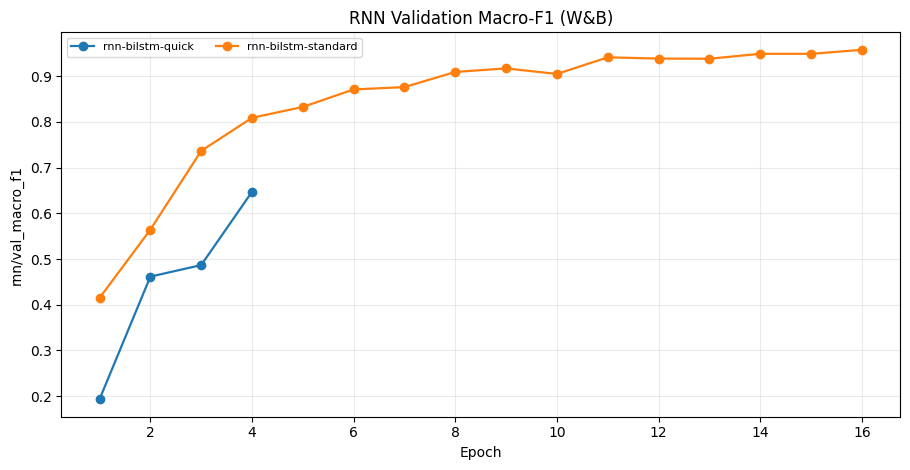

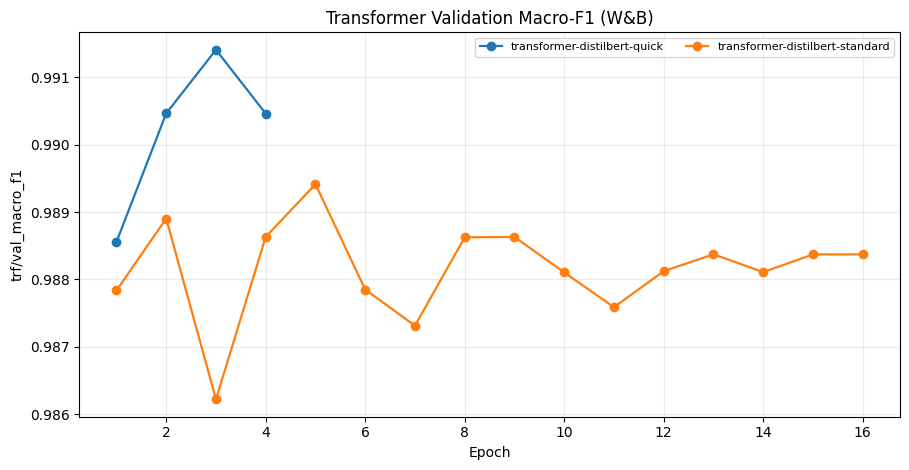

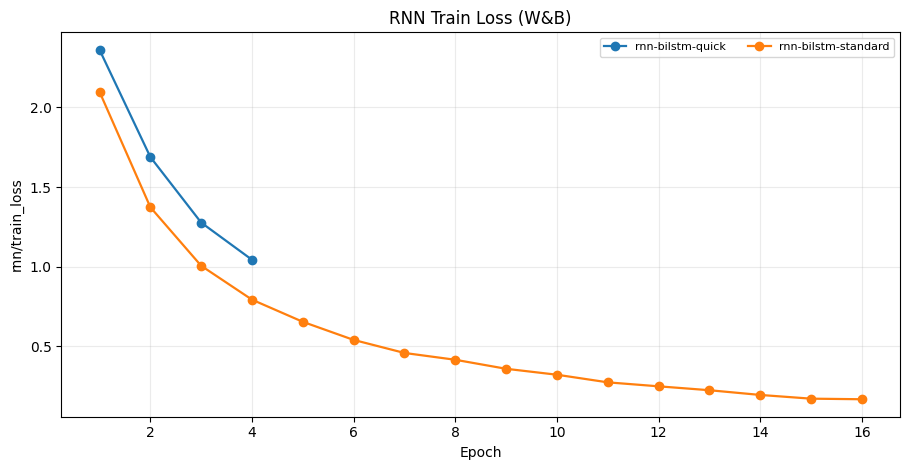

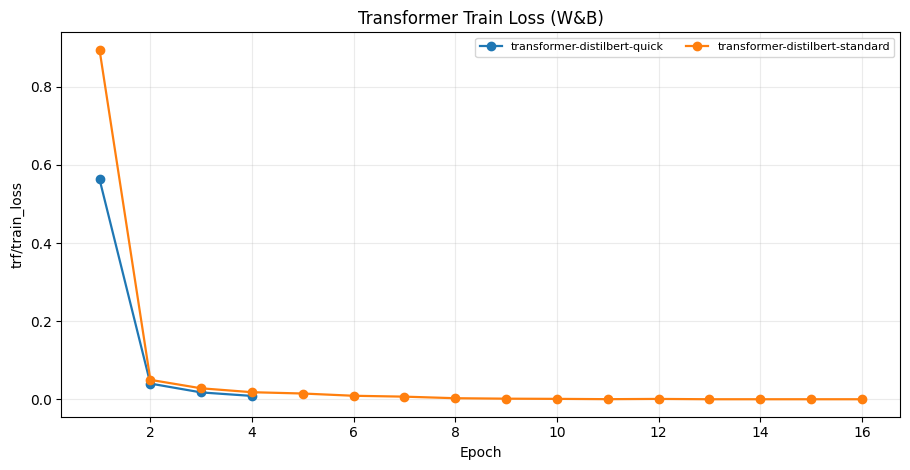

HTTPError: 500 Server Error: Internal Server Error for url: https://api.wandb.ai/graphql

In [26]:
# W&B inline plotting + dashboard embed
from IPython.display import HTML, IFrame, display

if not ENABLE_WANDB or wandb is None:
    print('W&B is disabled or unavailable in this kernel. Set ENABLE_WANDB=1 and rerun Cell 3.')
else:
    def resolve_wandb_entity() -> str | None:
        if WANDB_ENTITY:
            return WANDB_ENTITY
        try:
            api = wandb.Api(timeout=60)
            viewer = api.viewer
            if isinstance(viewer, dict):
                return viewer.get('entity') or viewer.get('username') or viewer.get('name')
            return getattr(viewer, 'entity', None) or getattr(viewer, 'username', None)
        except Exception:
            return None

    entity = resolve_wandb_entity()
    if not entity:
        print('Cannot resolve W&B entity. Set WANDB_ENTITY in Cell 3, then rerun this cell.')
    else:
        project_path = f"{entity}/{WANDB_PROJECT}"
        print('W&B project:', project_path)

        def epoch_proxy(run) -> float:
            s = getattr(run, 'summary', {}) or {}
            if isinstance(s, dict):
                ep = s.get('epoch', s.get('_step', -1))
            else:
                ep = getattr(s, 'get', lambda *args, **kwargs: -1)('epoch', -1)
                if ep == -1:
                    ep = getattr(s, 'get', lambda *args, **kwargs: -1)('_step', -1)
            try:
                return float(ep)
            except Exception:
                return -1.0

        def dedupe_runs_by_name(runs):
            # Keep run with the largest epoch proxy (then prefer finished, then latest).
            buckets = {}
            for r in runs:
                rn = (r.name or r.id).strip()
                buckets.setdefault(rn, []).append(r)

            picked = []
            for rn, arr in buckets.items():
                arr = sorted(
                    arr,
                    key=lambda x: (
                        epoch_proxy(x),
                        1 if (getattr(x, 'state', '') == 'finished') else 0,
                        str(getattr(x, 'created_at', '') or ''),
                    ),
                    reverse=True,
                )
                picked.append(arr[0])

            if len(runs) != len(picked):
                print(f'Deduped runs by name: {len(runs)} -> {len(picked)}')
            return picked

        def fetch_runs_with_prefix(prefixes: tuple[str, ...], max_runs: int = 120, only_finished: bool = False):
            api = wandb.Api(timeout=60)
            runs = api.runs(project_path, per_page=max_runs)
            chosen = []
            for r in runs:
                rn = (r.name or '').strip()
                if not any(rn.startswith(p) for p in prefixes):
                    continue
                if only_finished and getattr(r, 'state', '') != 'finished':
                    continue
                chosen.append(r)
            return dedupe_runs_by_name(chosen)

        def full_history_dataframe(run, metric_key: str) -> pd.DataFrame:
            # scan_history gets unsampled rows, unlike history() which can be downsampled.
            rows = []
            for row in run.scan_history(keys=['epoch', metric_key]):
                ep = row.get('epoch')
                val = row.get(metric_key)
                if ep is None or val is None:
                    continue
                rows.append({'epoch': ep, metric_key: val})
            if not rows:
                return pd.DataFrame(columns=['epoch', metric_key])
            df = pd.DataFrame(rows)
            df = df.dropna().sort_values('epoch')
            # If there are duplicate epoch logs, keep the last one for each epoch.
            df = df.groupby('epoch', as_index=False).last()
            return df

        def plot_metric_from_runs(runs, metric_key: str, title: str):
            plt.figure(figsize=(9.2, 4.8))
            plotted = 0
            for r in runs:
                try:
                    h = full_history_dataframe(r, metric_key)
                    if h.empty:
                        continue
                    label = (r.name or r.id)[:42]
                    if len(h) == 1:
                        plt.scatter(h['epoch'], h[metric_key], s=42, label=label)
                    else:
                        plt.plot(h['epoch'], h[metric_key], marker='o', linewidth=1.6, label=label)
                    plotted += 1
                except Exception:
                    continue

            if plotted == 0:
                plt.close()
                print(f'No plottable history for: {metric_key}')
                return

            plt.title(title)
            plt.xlabel('Epoch')
            plt.ylabel(metric_key)
            plt.grid(alpha=0.25)
            plt.legend(fontsize=8, ncol=2)
            plt.tight_layout()
            plt.show()

        main_runs = fetch_runs_with_prefix(
            ('rnn-bilstm-', 'transformer-distilbert-'),
            max_runs=200,
            only_finished=True,
        )
        if not main_runs:
            print('No finished main runs found in W&B yet. Run training cells first.')
        else:
            run_diag = pd.DataFrame([
                {
                    'name': r.name,
                    'state': getattr(r, 'state', ''),
                    'epoch_proxy': epoch_proxy(r),
                    'url': getattr(r, 'url', ''),
                }
                for r in main_runs
            ]).sort_values(['name']).reset_index(drop=True)
            print('Main runs selected:')
            display(run_diag)

            plot_metric_from_runs(main_runs, 'rnn/val_macro_f1', 'RNN Validation Macro-F1 (W&B)')
            plot_metric_from_runs(main_runs, 'trf/val_macro_f1', 'Transformer Validation Macro-F1 (W&B)')
            plot_metric_from_runs(main_runs, 'rnn/train_loss', 'RNN Train Loss (W&B)')
            plot_metric_from_runs(main_runs, 'trf/train_loss', 'Transformer Train Loss (W&B)')

        ablation_runs = fetch_runs_with_prefix(('ablation-c',), max_runs=300, only_finished=False)
        if ablation_runs:
            print('Found ablation runs:', len(ablation_runs))
            plot_metric_from_runs(ablation_runs, 'ablation/val_macro_f1', 'Ablation Validation Macro-F1 (W&B)')
            plot_metric_from_runs(ablation_runs, 'ablation/train_loss', 'Ablation Train Loss (W&B)')

        project_url = f"https://wandb.ai/{project_path}"
        print('Open full dashboard:', project_url)
        display(HTML(f'<p><a href="{project_url}" target="_blank">{project_url}</a></p>'))
        display(IFrame(src=project_url, width='100%', height=760))

## 7. Live Demo (Gradio + Hugging Face Space)

This section adds:
- Direct one-text inference with confidence + latency.
- In-notebook Gradio launcher.
- Helper to export a Hugging Face Space scaffold (`app.py`, `requirements.txt`, `README.md`).

In [27]:
# 7.1 Single-text inference demo (works with trained model if available, fallback otherwise)
if 'np' not in globals():
    import numpy as np
if 'torch' not in globals():
    import torch
if 'time' not in globals():
    import time


def _ensure_demo_tokenizer() -> bool:
    if 'tokenizer' in globals():
        return True
    if 'AutoTokenizer' in globals():
        model_name = str(globals().get('MODEL_NAME', 'distilbert-base-uncased'))
        tokenizer_obj = AutoTokenizer.from_pretrained(model_name)
        globals()['tokenizer'] = tokenizer_obj
        print(f"Loaded tokenizer fallback from '{model_name}'.")
        return True
    return False


def _ensure_demo_label_names(min_size: int = 14):
    if 'label_names' in globals() and len(label_names) > 0:
        return

    n = int(globals().get('num_labels', min_size))
    if 'trf_model' in globals():
        try:
            n = int(trf_model.config.num_labels)
        except Exception:
            pass

    globals()['label_names'] = [f'label_{i}' for i in range(max(n, 1))]
    print(f"Using fallback label names with count={len(label_names)}.")


def _ensure_demo_transformer() -> bool:
    if 'trf_model' in globals():
        return True
    if 'DistilBertForSequenceClassification' not in globals():
        return False

    model_name = str(globals().get('MODEL_NAME', 'distilbert-base-uncased'))
    nlab = int(globals().get('num_labels', len(globals().get('label_names', [])) or 14))
    model_obj = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=max(nlab, 2)).to(DEVICE)
    model_obj.eval()
    globals()['trf_model'] = model_obj
    print(f"Loaded transformer fallback model from '{model_name}' (not fine-tuned).")
    return True


@torch.no_grad()
def predict_single_text(text: str, model_key: str = 'transformer', max_len: int | None = None):
    if not _ensure_demo_tokenizer():
        raise RuntimeError('Tokenizer unavailable. Run setup cells first.')

    _ensure_demo_label_names()

    max_len_eff = int(max_len or globals().get('MAX_LEN', 128))
    enc = tokenizer(
        str(text),
        truncation=True,
        padding='max_length',
        max_length=max_len_eff,
        return_tensors='pt',
    )

    input_ids = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    k = model_key.strip().lower()
    if k in {'transformer', 'trf', 'distilbert'}:
        if 'trf_model' not in globals() and not _ensure_demo_transformer():
            raise RuntimeError('trf_model unavailable.')
        logits = trf_model(input_ids=input_ids, attention_mask=attention_mask).logits

    elif k in {'rnn', 'bilstm'}:
        if 'rnn_model' not in globals():
            raise RuntimeError('rnn_model unavailable. Run RNN training first.')
        if 'rnn_backend_context' in globals():
            with rnn_backend_context():
                logits = rnn_model(input_ids=input_ids, attention_mask=attention_mask)
        else:
            logits = rnn_model(input_ids=input_ids, attention_mask=attention_mask)

    elif k in {'ensemble', 'ens'}:
        if 'rnn_model' not in globals():
            raise RuntimeError('rnn_model unavailable. Ensemble requires RNN + Transformer.')
        if 'trf_model' not in globals() and not _ensure_demo_transformer():
            raise RuntimeError('trf_model unavailable for ensemble.')

        if 'rnn_backend_context' in globals():
            with rnn_backend_context():
                logits_rnn = rnn_model(input_ids=input_ids, attention_mask=attention_mask)
        else:
            logits_rnn = rnn_model(input_ids=input_ids, attention_mask=attention_mask)
        logits_trf = trf_model(input_ids=input_ids, attention_mask=attention_mask).logits

        p_rnn = torch.softmax(logits_rnn, dim=1)
        p_trf = torch.softmax(logits_trf, dim=1)
        ent_rnn = -(p_rnn * torch.log(p_rnn + 1e-12)).sum(dim=1)
        ent_trf = -(p_trf * torch.log(p_trf + 1e-12)).sum(dim=1)
        conf_rnn = 1.0 - ent_rnn / np.log(p_rnn.shape[1])
        conf_trf = 1.0 - ent_trf / np.log(p_trf.shape[1])
        w_rnn = conf_rnn / (conf_rnn + conf_trf + 1e-12)
        logits = w_rnn.unsqueeze(1) * logits_rnn + (1.0 - w_rnn).unsqueeze(1) * logits_trf

    else:
        raise ValueError("model_key must be one of: 'transformer', 'rnn', 'ensemble'")

    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000.0

    probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
    pred_id = int(np.argmax(probs))
    pred_label = label_names[pred_id] if pred_id < len(label_names) else f'label_{pred_id}'

    return {
        'model': model_key,
        'pred_id': pred_id,
        'pred_label': str(pred_label),
        'confidence': float(probs[pred_id]),
        'inference_ms': float(elapsed_ms),
    }


demo_texts = [
    'The football team won the national championship after a dramatic final match.',
    'Researchers introduced a more efficient transformer architecture for long context.',
    'A new electric vehicle model announced improved battery and autonomous driving features.',
]

demo_rows = []
for txt in demo_texts:
    for mk in ['transformer', 'rnn', 'ensemble']:
        try:
            out = predict_single_text(txt, model_key=mk)
            out['text_preview'] = txt[:90] + ('...' if len(txt) > 90 else '')
            demo_rows.append(out)
        except Exception:
            continue

demo_df = pd.DataFrame(demo_rows)
if demo_df.empty:
    print('No demo output yet. Need at least one available model in memory.')
else:
    demo_df[['text_preview', 'model', 'pred_label', 'confidence', 'inference_ms']]

In [28]:
# 7.2 Launch Gradio and export Hugging Face Space scaffold
from pathlib import Path
from textwrap import dedent


def launch_text_demo_gradio(share: bool = False):
    try:
        gr = importlib.import_module('gradio')
    except Exception as e:
        print(f"Gradio unavailable ({type(e).__name__}: {e}). Install with: %pip install gradio")
        return None

    available_models = []
    if 'trf_model' in globals() or _ensure_demo_transformer():
        available_models.append('transformer')
    if 'rnn_model' in globals():
        available_models.append('rnn')
    if 'rnn_model' in globals() and ('trf_model' in globals() or _ensure_demo_transformer()):
        available_models.append('ensemble')

    if not available_models:
        print('No model available for Gradio demo.')
        return None

    def _ui_fn(text, model_name):
        out = predict_single_text(text, model_key=model_name)
        pred_msg = f"Label={out['pred_label']} (id={out['pred_id']})"
        return pred_msg, out['confidence'], out['inference_ms']

    demo = gr.Interface(
        fn=_ui_fn,
        inputs=[
            gr.Textbox(lines=6, label='Input Text', placeholder='Enter text for classification...'),
            gr.Dropdown(choices=available_models, value=available_models[0], label='Model'),
        ],
        outputs=[
            gr.Textbox(label='Prediction'),
            gr.Number(label='Confidence'),
            gr.Number(label='Inference time (ms)'),
        ],
        title='DBPedia Text Classification Demo',
        description='In-notebook Gradio demo for quick testing.',
    )

    return demo.launch(share=share, inline=True)


def export_hf_space_text_demo(space_dir: str = 'notebooks/hf_space_text_demo'):
    target = Path(space_dir)
    target.mkdir(parents=True, exist_ok=True)

    app_py = dedent('''
    import os
    import time
    import torch
    import gradio as gr
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    MODEL_ID = os.getenv("HF_SPACE_MODEL_ID", "distilbert-base-uncased")
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


    def _load_model_and_tokenizer():
        tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
        try:
            model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
        except Exception:
            model = AutoModelForSequenceClassification.from_pretrained(
                "distilbert-base-uncased",
                num_labels=14,
            )

        model.to(DEVICE)
        model.eval()

        label_names = [f"label_{i}" for i in range(int(getattr(model.config, "num_labels", 14)))]
        return tokenizer, model, label_names


    tokenizer, model, label_names = _load_model_and_tokenizer()


    @torch.no_grad()
    def predict_text(text: str):
        text = str(text or "").strip()
        if not text:
            return "Please enter text.", 0.0, 0.0

        enc = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt",
        )

        input_ids = enc["input_ids"].to(DEVICE)
        attention_mask = enc["attention_mask"].to(DEVICE)

        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        if DEVICE == "cuda":
            torch.cuda.synchronize()

        elapsed_ms = (time.perf_counter() - t0) * 1000.0

        probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
        pred_id = int(probs.argmax())
        pred_label = label_names[pred_id] if pred_id < len(label_names) else f"label_{pred_id}"

        return f"Label={pred_label} (id={pred_id})", float(probs[pred_id]), float(elapsed_ms)


    demo = gr.Interface(
        fn=predict_text,
        inputs=gr.Textbox(lines=6, label="Input Text", placeholder="Enter text for classification..."),
        outputs=[
            gr.Textbox(label="Prediction"),
            gr.Number(label="Confidence"),
            gr.Number(label="Inference time (ms)"),
        ],
        title="DBPedia Text Classification Demo",
        description="Set HF_SPACE_MODEL_ID to your fine-tuned model on Hugging Face Hub.",
    )


    if __name__ == "__main__":
        demo.launch()
    ''').strip() + '\n'

    req_txt = dedent('''
    gradio>=5.0.0
    transformers>=4.48.0
    torch>=2.2.0
    ''').strip() + '\n'

    readme_md = dedent('''
    ---
    title: dbpedia-text-demo
    sdk: gradio
    app_file: app.py
    ---

    # DBPedia Text Classification Demo

    ## Configure model
    - In Space Settings -> Variables, set `HF_SPACE_MODEL_ID` to your fine-tuned model repo.
    - If not set, app falls back to a generic DistilBERT classifier head.

    ## Local test
    ```bash
    pip install -r requirements.txt
    python app.py
    ```
    ''').strip() + '\n'

    (target / 'app.py').write_text(app_py, encoding='utf-8')
    (target / 'requirements.txt').write_text(req_txt, encoding='utf-8')
    (target / 'README.md').write_text(readme_md, encoding='utf-8')

    print('Exported HF Space scaffold to:', target)
    return str(target)


print('Run in notebook: launch_text_demo_gradio(share=False)')
print('Export Space scaffold: export_hf_space_text_demo()')

Run in notebook: launch_text_demo_gradio(share=False)
Export Space scaffold: export_hf_space_text_demo()


In [29]:
# Quick demo summary + Hugging Face Space scaffold export
if 'demo_df' in globals() and not demo_df.empty:
    cols = [c for c in ['text_preview', 'model', 'pred_label', 'confidence', 'inference_ms'] if c in demo_df.columns]
    print('demo_df rows:', len(demo_df))
    display(demo_df[cols].head(10))
else:
    print('demo_df is empty or unavailable.')

if 'export_hf_space_text_demo' in globals():
    export_path = export_hf_space_text_demo()
    print('HF Space scaffold path:', export_path)
else:
    print('export_hf_space_text_demo is not available yet.')

demo_df rows: 9


,text_preview,model,pred_label,confidence,inference_ms
0,The football team won the national championshi...,transformer,EducationalInstitution,0.993430,10.476414
1,The football team won the national championshi...,rnn,Athlete,0.733346,23.444909
2,The football team won the national championshi...,ensemble,EducationalInstitution,0.880390,60.376338
3,Researchers introduced a more efficient transf...,transformer,Company,0.940188,8.543659
4,Researchers introduced a more efficient transf...,rnn,Plant,0.208271,3.379867
5,Researchers introduced a more efficient transf...,ensemble,Company,0.920777,12.871499
6,A new electric vehicle model announced improve...,transformer,MeanOfTransportation,1.000000,8.865721
7,A new electric vehicle model announced improve...,rnn,MeanOfTransportation,0.224671,3.557994
8,A new electric vehicle model announced improve...,ensemble,MeanOfTransportation,0.999999,11.684228


Exported HF Space scaffold to: notebooks/hf_space_text_demo
HF Space scaffold path: notebooks/hf_space_text_demo


In [30]:
# Lưu cả model và tokenizer vào một thư mục mới
trf_model.save_pretrained('./notebooks/hf_space_text_demo/distilbert_model')
tokenizer.save_pretrained('./notebooks/hf_space_text_demo/distilbert_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./notebooks/hf_space_text_demo/distilbert_model/tokenizer_config.json',
 './notebooks/hf_space_text_demo/distilbert_model/tokenizer.json')

In [31]:
# Lưu trọng số (state_dict) của PyTorch
torch.save(rnn_model.state_dict(), './notebooks/hf_space_text_demo/rnn_model.pt')